# 🤖 04. Asistente LLM para Diagnóstico de Causa Raíz (RCA) Multimodal
**Benchmark Comparativo Multi-Modelo (`gemini-3.5-flash`, `gemini-3.1-flash-lite`, `deepseek-r1:14b`), Auditoría de Prompts y Demostración Empírica de NeuralLog**

---

### 📌 1. Contexto Teórico y Rol del Asistente LLM en el TFM

En las etapas precedentes de este Trabajo de Fin de Máster hemos construido y evaluado los componentes especializados de observabilidad:
1. **Series Temporales (Métricas):** El modelo **TranAD+** (*Paso 2*) detectó las ventanas temporales de fallo e identificó las métricas con mayor desvío de reconstrucción ($c_{t,i}$).
2. **Topología y Linaje (Grafo DAG):** El módulo **Topology Mapper** mapeó las métricas con alto desvío a los componentes y tareas sospechosas a lo largo de la arquitectura distribuida (Emisor $\to$ Kinesis $\to$ Airflow $\to$ PostgreSQL DW).
3. **Evidencia Textual de Logs (NLP Denso):** El algoritmo **NeuralLog** (*Paso 3*) filtró más del $97.6\%$ del ruido rutinario (mensajes `INFO`) y seleccionó los **Top-$K$ logs más atípicos** con representaciones semánticas densas.

Sin embargo, estos tres componentes generan datos heterogéneos y dispersos. El objetivo de este **Cuaderno 4** es implementar y contrastar empíricamente el **Asistente de Causa Raíz (RCA)** basado en Modelos de Lenguaje de Gran Escala (**LLM**), que actúa como el **motor de síntesis multimodal y razonamiento causal**:

```
+-----------------------------------------------------------------------------------------------+
|                                ARQUITECTURA MULTIMODAL AIOps                                  |
+-----------------------------------------------------------------------------------------------+
|  1. MÉTRICAS (TranAD+)           2. GRAFO / LINAJE (Topology)      3. LOGS (NeuralLog)        |
|     - Ventana [T_ini, T_fin]        - Mapeo candidatos                - Top-K atípicos        |
|     - Desvío de variables           - Propagación de flujo            - Ruido descartado (>97%)|
+----------------------------------------+------------------------------------+-----------------+
                                         |
                                         v
+-----------------------------------------------------------------------------------------------+
|                     4. ASISTENTE LLM DE CAUSA RAÍZ (ESTE CUADERNO 4)                          |
|                                                                                               |
|  - Visor colapsable (<details>) del prompt multimodal exacto para auditoría SRE bajo demanda  |
|  - Benchmark Comparativo Multi-Modelo evaluando 3 LLMs en los 3 incidentes del benchmark:     |
|      1) gemini-3.5-flash: Modelo frontera Cloud con razonamiento analítico causal reflexivo   |
|      2) gemini-3.1-flash-lite: Modelo Cloud optimizado para ultra-baja latencia y alto triage |
|      3) deepseek-r1:14b: Modelo Open-Source On-Premises en GPU local vía Ollama (Privacidad)  |
|  - Evaluación cuantitativa objetiva en 4 dimensiones contra el Ground Truth                   |
|  - Tabla comparativa por incidente y tabla final de promedios agregados                       |
|  - Selección automática del LLM Ganador                                                       |
|  - Estudio de Ablación sobre el LLM Ganador: Demostración Empírica del Valor de NeuralLog     |
+-----------------------------------------------------------------------------------------------+
```

---

### 🔬 2. Principios de Diseño del Asistente LLM

1. **Abstracción Agnóstica de Proveedores (`llm_client.py`):** Unifica la interfaz de llamada tanto para modelos comerciales de nube (Google Gemini mediante el SDK `google-genai`) como para modelos de pesos abiertos locales (`deepseek-r1:14b` vía Ollama sobre LiteLLM).
2. **Seguridad Estricta de Credenciales:** Todas las claves de API se gestionan mediante variables de entorno y archivos `.env` (cargados vía `python-dotenv`). Ningún token sensible se expone en código ni en salidas.
3. **Auditoría de Prompts Limpia pero Accesible:** Los prompts multimodales ensamblados se presentan en la interfaz Jupyter mediante elementos colapsables HTML (`<details>`), manteniéndose cerrados por defecto para no saturar el espacio visual pero accesibles con un solo clic.
4. **Aislamiento de Razonamiento (*Chain-of-Thought*):** Los modelos reflexivos (`gemini-3.5-flash`, `deepseek-r1:14b`) generan reflexiones internas extensas. Nuestra arquitectura desacopla el pensamiento del informe técnico final, permitiendo inspeccionar la cadena de deducción causal en acordeones interactivos sin ensuciar el informe ejecutivo.


## ⚙️ 1. Definición del Benchmark Multi-Modelo y Carga Segura de Credenciales

Para evaluar objetivamente qué modelo ofrece el mejor equilibrio entre **precisión diagnóstica**, **latencia de respuesta**, **profundidad causal** y **viabilidad operativa**, configuramos tres modelos representativos de diferentes paradigmas arquitectónicos:

| Modelo | Proveedor | Paradigma / Rol | Justificación para AIOps |
| :--- | :--- | :--- | :--- |
| **`gemini-3.5-flash`** | Google Gemini (Cloud) | *Cloud Frontier Reasoning* | Razonamiento reflexivo explícito (*Chain-of-Thought* nativo), alta deducción causal y seguimiento estricto de directrices SRE. |
| **`gemini-3.1-flash-lite`** | Google Gemini (Cloud) | *Cloud Low-Latency Triage* | Optimizado para velocidad extrema y bajo consumo de tokens. Ideal para triajes preliminares en tiempo real. |
| **`deepseek-r1:14b`** | Ollama (Local GPU) | *Open-Source On-Premises* | Soberanía total de datos y coste marginal cero. Permite procesar telemetría y logs confidenciales dentro del perímetro corporativo sin salida a Internet. |

> [!IMPORTANT]
> **Presupuesto de Tokens y Delays de Tasa (Rate Limiting):**
> - En modelos de razonamiento, el proceso reflexivo y el reporte final comparten el cupo de salida (`max_output_tokens`). Fijamos `max_tokens: 4096` para evitar truncamientos accidentales (`MAX_TOKENS`).
> - Se introduce una pausa de cortesía (`time.sleep(5)`) entre llamadas sucesivas para respetar las cuotas por minuto del Free Tier de Google AI Studio y evitar errores `429 Too Many Requests` o `503 High Demand`.


In [25]:
import os

# =============================================================================
# ⚙️ CONFIGURACIÓN DEL BENCHMARK COMPARATIVO MULTI-MODELO (3 LLMs)
# =============================================================================

BENCHMARK_MODELS = [
    {
        "model_id": "gemini-3.5-flash",
        "provider": "gemini",
        "display_name": "Gemini 3.5 Flash",
        "role": "Cloud Reasoning (CoT Reflexivo)",
        "temperature": 0.2,
        "max_tokens": 4096,
        "timeout": 180
    },
    {
        "model_id": "gemini-3.1-flash-lite",
        "provider": "gemini",
        "display_name": "Gemini 3.1 Flash-Lite",
        "role": "Cloud Fast (Baja Latencia / Triage)",
        "temperature": 0.2,
        "max_tokens": 4096,
        "timeout": 180
    },
    {
        "model_id": "deepseek-r1:14b",
        "provider": "ollama",
        "display_name": "DeepSeek-R1:14b",
        "role": "Local GPU On-Prem (Privacidad Total)",
        "temperature": 0.2,
        "max_tokens": 4096,
        "timeout": 300,
        "api_base": "http://localhost:11434"
    }
]

# =============================================================================
# ⚖️ CONFIGURACIÓN DEL EVALUADOR CIEGO (LLM-AS-A-JUDGE)
# =============================================================================
# Modelo asignado como Juez SRE imparcial para evaluar diagnósticos frente al Ground Truth.
JUDGE_MODEL_ID = "gemini-3.1-flash-lite"

POLITE_SLEEP_SECONDS = 5  # Pausa entre llamadas a APIs para evitar saturación y 429

# =============================================================================
# 📁 DIRECTORIO DE SALIDA PARA ARTEFACTOS DEL CUADERNO 4
# =============================================================================
OUTPUT_DIR = "llms_output"
os.makedirs(OUTPUT_DIR, exist_ok=True)
CACHE_FILE_PATH = os.path.join(OUTPUT_DIR, "cached_llm_responses.json")

# Migración automática si existe caché previa en processed_data
legacy_cache_path = "processed_data/cached_llm_responses.json"
if not os.path.exists(CACHE_FILE_PATH) and os.path.exists(legacy_cache_path):
    import shutil
    shutil.copyfile(legacy_cache_path, CACHE_FILE_PATH)
    print(f"📦 Caché previa migrada automáticamente a: {CACHE_FILE_PATH}")

def _atomic_update_cache(update_fn):
    # Actualiza atómicamente el archivo de caché en llms_output/cached_llm_responses.json
    # utilizando un archivo temporal (.tmp) y reemplazo atómico para evitar corrupción.
    cache_path = CACHE_FILE_PATH
    data = {}
    if os.path.exists(cache_path):
        try:
            with open(cache_path, "r", encoding="utf-8") as fc:
                data = json.load(fc)
        except Exception:
            data = {}
    
    update_fn(data)
    
    tmp_path = f"{cache_path}.tmp"
    with open(tmp_path, "w", encoding="utf-8") as fc:
        json.dump(data, fc, indent=2, ensure_ascii=False)
    os.replace(tmp_path, cache_path)

# =============================================================================
# ⚙️ CONTROL DE CACHÉ DE INFERENCIA LLM
# =============================================================================
# Establecer en True para reutilizar respuestas verificadas en caché (reproducibilidad y velocidad).
# Establecer en False para forzar llamadas en vivo a las APIs de los LLMs.
# NOTA: Incluso con USE_CACHED_LLM_RESPONSES = False, todas las respuestas generadas
# y evaluaciones del Juez se guardan SIEMPRE en llms_output/cached_llm_responses.json
# (patrón Write-Through atómico llamada a llamada).
USE_CACHED_LLM_RESPONSES = True

print(f"📁 Directorio de artefactos configurado: '{OUTPUT_DIR}/'")
print(f"💾 Caché central configurada: '{CACHE_FILE_PATH}' (Modo {'Lectura/Escritura' if USE_CACHED_LLM_RESPONSES else 'Write-Through Fresco'})")
print(f"⚖️ Juez SRE (LLM-as-a-Judge) configurado: '{JUDGE_MODEL_ID}' (temperatura=0.0 determinista)")
print(f"✅ Benchmark Multi-Modelo configurado ({len(BENCHMARK_MODELS)} modelos):")
for m in BENCHMARK_MODELS:
    endpoint_str = m.get("api_base", "Google Cloud API (.env)")
    print(f"   • {m['display_name']:<22} | Proveedor: {m['provider']:<8} | Endpoint: {endpoint_str:<26} | Rol: {m['role']}")


📁 Directorio de artefactos configurado: 'llms_output/'
💾 Caché central configurada: 'llms_output/cached_llm_responses.json' (Modo Lectura/Escritura)
⚖️ Juez SRE (LLM-as-a-Judge) configurado: 'gemini-3.1-flash-lite' (temperatura=0.0 determinista)
✅ Benchmark Multi-Modelo configurado (3 modelos):
   • Gemini 3.5 Flash       | Proveedor: gemini   | Endpoint: Google Cloud API (.env)    | Rol: Cloud Reasoning (CoT Reflexivo)
   • Gemini 3.1 Flash-Lite  | Proveedor: gemini   | Endpoint: Google Cloud API (.env)    | Rol: Cloud Fast (Baja Latencia / Triage)
   • DeepSeek-R1:14b        | Proveedor: ollama   | Endpoint: http://localhost:11434     | Rol: Local GPU On-Prem (Privacidad Total)


## 🔌 2. Capa de Abstracción Unificada con LiteLLM y `llm_client.py`

El módulo [`llm_client.py`](file://llm_client.py) encapsula la complejidad de comunicación con múltiples proveedores:
1. **Renderizado Enriquecido de Markdown:** Integra el método `.display()` que aprovecha `IPython.display.Markdown` para renderizar encabezados, listas y negritas tipográficamente nativas.
2. **Extracción y Desacoplamiento de CoT:** Separa las reflexiones internas (`candidate.parts.thought` en Gemini y `<think>` en DeepSeek) del reporte final para mantener una salida ejecutiva limpia pero auditable.
3. **Purga de Preámbulos:** Elimina saludos conversacionales para garantizar informes técnicos homogéneos.

A continuación inicializamos los clientes para cada modelo del benchmark y ejecutamos un test de humo (*smoke test*) para verificar la conectividad de la plataforma.


In [26]:
import os
import json
import time
import logging
logging.getLogger("google").setLevel(logging.ERROR)
logging.getLogger("google.genai").setLevel(logging.ERROR)
logging.getLogger("google.genai.models").setLevel(logging.ERROR)
logging.getLogger("google_genai").setLevel(logging.ERROR)
logging.getLogger("google_genai.models").setLevel(logging.ERROR)
from IPython.display import display, Markdown, HTML
from llm_client import UnifiedLLMClient, LLMResponse

# 1. Inicializar clientes unificados para cada modelo del benchmark
clients = {}
print("🔌 Inicializando clientes unificados para el benchmark...")

for m_cfg in BENCHMARK_MODELS:
    m_id = m_cfg["model_id"]
    client = UnifiedLLMClient(
        provider=m_cfg["provider"],
        model=m_id,
        api_base=m_cfg.get("api_base"),
        temperature=m_cfg["temperature"],
        max_tokens=m_cfg["max_tokens"],
        timeout=m_cfg["timeout"]
    )
    clients[m_id] = client
    cfg_safe = client.get_safe_config()
    print(f"  ✓ {m_cfg['display_name']:<22}: provider={cfg_safe['provider']:<8} | key_ok={str(cfg_safe['api_key_configured']):<5} | endpoint={cfg_safe['api_base'] or 'Google Cloud API'}")

# Garantizar que el modelo juez esté inicializado en el mapa de clientes
if JUDGE_MODEL_ID not in clients:
    judge_provider = "gemini" if "gemini" in JUDGE_MODEL_ID else "ollama"
    clients[JUDGE_MODEL_ID] = UnifiedLLMClient(
        provider=judge_provider,
        model=JUDGE_MODEL_ID,
        temperature=0.0
    )
    print(f"  ✓ Juez SRE ({JUDGE_MODEL_ID}): inicializado como evaluador independiente.")

# 2. Test de humo rápido de conectividad (Smoke Test) con el Juez SRE
print(f"\n⚡ Ejecutando test de humo con el Juez SRE '{JUDGE_MODEL_ID}'...")
smoke_prompt = "Calcula 2+2 y responde exactamente con este formato:\n### 1. Diagnóstico\nEl resultado de la operación es **4**."
try:
    smoke_resp = clients[JUDGE_MODEL_ID].generate(
        user_prompt=smoke_prompt,
        system_prompt="Eres un asistente conciso de observabilidad y SRE."
    )
    print(f"⏱️ Latencia de respuesta: {smoke_resp.latency_seconds:.2f}s | Tokens: {smoke_resp.total_tokens}")
    print(f"🧠 Razonamiento intermedio (CoT) detectado: {'Sí (' + str(len(smoke_resp.thinking)) + ' caracteres)' if smoke_resp.thinking else 'No'}")
    print("\n📋 Salida renderizada en Markdown:")
    smoke_resp.display()
except Exception as e:
    print(f"⚠️ Nota de conectividad en test de humo: {e}")
time.sleep(POLITE_SLEEP_SECONDS)


🔌 Inicializando clientes unificados para el benchmark...
  ✓ Gemini 3.5 Flash      : provider=gemini   | key_ok=True  | endpoint=Google Cloud API
  ✓ Gemini 3.1 Flash-Lite : provider=gemini   | key_ok=True  | endpoint=Google Cloud API
  ✓ DeepSeek-R1:14b       : provider=ollama   | key_ok=False | endpoint=http://localhost:11434

⚡ Ejecutando test de humo con el Juez SRE 'gemini-3.1-flash-lite'...
⏱️ Latencia de respuesta: 1.04s | Tokens: 60
🧠 Razonamiento intermedio (CoT) detectado: No

📋 Salida renderizada en Markdown:


### 1. Diagnóstico
El resultado de la operación es **4**.

## 📦 3. Ingesta del Paquete Multimodal de Diagnóstico

Cargamos las evidencias estructuradas generadas en los pasos previos del TFM:
- **`processed_data/selected_relevant_logs_for_rca.json`**: Contiene los incidentes del conjunto de test con sus ventanas temporales, métricas afectadas identificadas por **TranAD+**, candidatos del **Topology Mapper** y los **Top-$K$ logs más relevantes** filtrados y rankeados por **NeuralLog**.
- **`dataset_gen/datasets_finales/test_rca_benchmark.json`**: Ground Truth oficial para contrastar la precisión de los diagnósticos.
- **`dataset_gen/topology_mapper.py`**: Grafo de linaje del pipeline para enriquecer el contexto arquitectónico.


In [27]:
import pandas as pd
from dataset_gen.topology_mapper import DATA_PIPELINE_DAG, ANOMALY_GROUND_TRUTH, get_components_for_metrics

# 1. Cargar incidentes de test preparados por TranAD+ y NeuralLog
with open("processed_data/selected_relevant_logs_for_rca.json", "r", encoding="utf-8") as f:
    rca_incidents = json.load(f)

# 2. Cargar benchmark con Ground Truth de causas raíz (exclusivamente para evaluación de rúbricas)
with open("dataset_gen/datasets_finales/test_rca_benchmark.json", "r", encoding="utf-8") as f:
    benchmark_cases = json.load(f)

# 3. Enriquecimiento operacional cuantitativo mediante inferencia de TranAD+
# NOTA DE INTEGRIDAD METODOLÓGICA (No Data Leakage):
# Leemos únicamente las columnas generadas en inferencia por la red neuronal (anomaly_score y contrib_*).
# La columna 'ground_truth' del CSV se ignora por completo, simulando un entorno real de producción.
df_detections = pd.read_csv("processed_data/test_detections.csv")
contrib_cols = [c for c in df_detections.columns if c.startswith("contrib_")]

for inc in rca_incidents:
    s, e = inc["window"]["start_epoch"], inc["window"]["end_epoch"]
    sub = df_detections[(df_detections["timestamp"] >= s) & (df_detections["timestamp"] <= e)]
    if len(sub) > 0:
        mean_score = float(sub["anomaly_score"].mean())
        max_score = float(sub["anomaly_score"].max())
        contrib_means = sub[contrib_cols].mean()
        total_contrib = contrib_means.sum() if contrib_means.sum() > 0 else 1.0
        ranked_contribs = []
        for col, val in contrib_means.sort_values(ascending=False).head(4).items():
            metric_name = col.replace("contrib_", "")
            pct = (val / total_contrib) * 100.0
            ranked_contribs.append({
                "metric": metric_name,
                "error_value": round(float(val), 4),
                "contribution_pct": round(float(pct), 2)
            })
        inc["tranad_evidence"]["quantitative_metrics"] = {
            "mean_anomaly_score": round(mean_score, 3),
            "max_anomaly_score": round(max_score, 3),
            "top_metric_contributions": ranked_contribs
        }

print(f"✅ Paquete multimodal cargado y enriquecido operacionalmente: {len(rca_incidents)} incidentes de evaluación en Test.")

summary_rows = []
for inc in rca_incidents:
    qm = inc["tranad_evidence"].get("quantitative_metrics", {})
    top_c = qm.get("top_metric_contributions", [])
    top_c_str = ", ".join([f"{c['metric']} ({c['contribution_pct']}%)" for c in top_c[:2]])
    summary_rows.append({
        "Incidente ID": inc["incident_id"],
        "Tipo Anomalía": inc["anomaly_type"],
        "Categoría": inc["category"],
        "Duración (s)": inc["window"]["duration_seconds"],
        "TranAD+ Score (Max/Mean)": f"{qm.get('max_anomaly_score', 0):.2f} / {qm.get('mean_anomaly_score', 0):.2f}",
        "TranAD+ Top Contribución": top_c_str,
        "Top Logs NeuralLog": len(inc["neurallog_top_logs"]),
        "Causa Raíz Real (Ground Truth)": inc["ground_truth"]["root_cause_summary"]
    })

pd.set_option('display.max_colwidth', None)
display(pd.DataFrame(summary_rows))


✅ Paquete multimodal cargado y enriquecido operacionalmente: 3 incidentes de evaluación en Test.


,Incidente ID,Tipo Anomalía,Categoría,Duración (s),TranAD+ Score (Max/Mean),TranAD+ Top Contribución,Top Logs NeuralLog,Causa Raíz Real (Ground Truth)
0,incident_000,dw_timeout,DATABASE_UNAVAILABLE,686,0.55 / 0.23,"cpu_usage (44.94%), memory_usage (32.39%)",10,"Interrupción / pausa del contenedor PostgreSQL Data Warehouse (analytics_db) en el puerto 5432, impidiendo la persistencia de lotes."
1,incident_001,emitter_down,SOURCE_PRODUCER_FAILURE,949,0.51 / 0.25,"emitter_memory_usage (27.24%), cpu_usage (24.44%)",10,Detención silenciosa del microservicio emisor de datos (kinesis_emitter) que inyecta telemetría continua al stream de Kinesis.
2,incident_002,aws_down,MESSAGE_BROKER_UNAVAILABLE,653,21.88 / 2.48,"emitter_memory_usage (49.87%), memory_usage (26.48%)",10,"Pausa / congelación del contenedor AWS LocalStack (Kinesis endpoint), manifestado a nivel de proceso por saturación de CPU y bloqueo del bucle de eventos asíncronos (CPU starvation en kinesis_mock_server) impidiendo responder a peticiones HTTP en el puerto 4566."


## 📝 4. Ingeniería de Prompts Estructurados y Visor Colapsable

Un diagnóstico técnico de alta fiabilidad requiere tres piezas metodológicas clave de *Prompt Engineering*:
1. **System Prompt Especializado:** Define el rol del modelo como *Ingeniero Principal de Datos y Especialista en SRE/Observabilidad*, imponiendo una estructura de reporte en 3 secciones fijas:
   - **`### 1. Diagnóstico de Causa Raíz (Root Cause)`**
   - **`### 2. Análisis de Propagación en Cascada (Downstream / Upstream Impact)`**
   - **`### 3. Acciones Técnicas de Remediación`**
2. **Fusión Multimodal Operacional sin Fuga de Información (*Zero Data Leakage*):**
   - **Top-10 Logs de NeuralLog:** Se transfieren los 10 logs seleccionados y diversificados por Sentence-BERT + Isolation Forest. Se elimina el truncamiento artificial a 5 logs, permitiendo al LLM observar evidencias críticas de propagación en cascada y fallo final en tareas downstream (p. ej., `TRIM_HORIZON` y fallo de tareas en Airflow).
   - **Señales Cuantitativas de TranAD+:** Se incorporan el error de reconstrucción pico y medio (`max_anomaly_score`, `mean_anomaly_score`) y la descomposición del error por variable (`contrib_*`). Estas magnitudes proceden exclusivamente de la inferencia no supervisada del modelo en streaming, prescindiendo de etiquetas de Ground Truth.
3. **Visor Colapsable de Prompts para Auditoría SRE:** Para posibilitar que los operadores revisen el texto exacto enviado a los LLMs sin saturar la lectura del cuaderno, encapsulamos cada prompt ensamblado en un elemento HTML `<details>` que permanece **colapsado por defecto** y puede desplegarse interactivamente.


In [28]:
import html

SYSTEM_PROMPT = """Eres un Ingeniero Principal de Datos y Especialista en SRE/Observabilidad de Pipelines Distribuidas de Datos.
Tu función es realizar el Análisis de Causa Raíz (RCA - Root Cause Analysis) y el diagnóstico técnico de anomalías detectadas en una pipeline de datos.

Se te proporcionará:
1. La topología y flujo del DAG del pipeline.
2. La ventana temporal y las métricas que el algoritmo de series temporales (TranAD+) identificó con alto error de reconstrucción.
3. Los logs extraídos de los componentes candidatos en dicha ventana temporal (filtrados y ordenados por relevancia semántica mediante NeuralLog).

Debes generar un informe conciso y estructurado con el siguiente formato EXACTO:
### 1. Diagnóstico de Causa Raíz (Root Cause)
- Componente origen del fallo.
- Motivo exacto del fallo basado en la evidencia de los logs y métricas.

### 2. Análisis de Propagación en Cascada (Downstream / Upstream Impact)
- Cómo afectó este problema a los componentes dependientes en el linaje de datos (retrasos, acumulación de lag, pérdida/bloqueo de registros).

### 3. Acciones Técnicas de Remediación
- Acciones inmediatas para mitigar el incidente.
- Medidas preventivas a medio/largo plazo en infraestructura o código.
"""

def build_multimodal_rca_prompt(incident: dict, mode: str = "multimodal", raw_logs_sample: list = None) -> str:
    """
    Construye el prompt multimodal combinando topología, métricas y logs.
    Soporta 3 modos experimentales para el estudio de ablación:
      - 'multimodal': Topología + TranAD+ cuantitativo + Top-10 logs seleccionados por NeuralLog.
      - 'no_logs': Topología + TranAD+ cuantitativo sin logs (aislamiento métrico).
      - 'raw_logs': Topología + TranAD+ cuantitativo + logs crudos rutinarios INFO (sin filtrado semántico).
    """
    topo = incident["topology_context"]
    window = incident["window"]
    candidates = topo["candidate_components"]
    
    # 1. Evidencia cuantitativa operacional de TranAD+ (sin etiquetas de Ground Truth)
    q_metrics = incident.get("tranad_evidence", {}).get("quantitative_metrics", {})
    max_score = q_metrics.get("max_anomaly_score", 0.0)
    mean_score = q_metrics.get("mean_anomaly_score", 0.0)
    top_contribs = q_metrics.get("top_metric_contributions", [])
    
    if top_contribs:
        contrib_lines = "\n".join([
            f"  {idx+1}. {c['metric']}: {c['contribution_pct']}% del error multivariante (error: {c.get('error_value', 0):.4f})"
            for idx, c in enumerate(top_contribs)
        ])
    else:
        metrics = incident.get("tranad_evidence", {}).get("expected_anomalous_metrics", [])
        contrib_lines = f"  - Métricas detectadas: {', '.join(metrics)}"

    # 2. Evidencia textual de Logs
    if mode == "multimodal":
        logs = incident.get("neurallog_top_logs", [])
        log_lines = []
        for idx, l in enumerate(logs[:10], 1):
            score = l.get("anomaly_score", 0.0)
            log_lines.append(f"[{idx}] [{l['component']}] [{l['level']}] (Score: {score:.3f}) {l['message']}")
        logs_str = "\n".join(log_lines) if log_lines else "(No se detectaron logs relevantes en la ventana)"
    elif mode == "no_logs":
        logs_str = "(Sin evidencia textual de logs disponible. Realiza el diagnóstico basándote exclusivamente en las métricas cuantitativas y la topología)"
    elif mode == "raw_logs":
        logs = raw_logs_sample or []
        log_lines = [
            f"[{idx}] [{l.get('component', 'unknown')}] [{l.get('level', 'INFO')}] {l.get('message', '')}"
            for idx, l in enumerate(logs[:10], 1)
        ]
        logs_str = "\n".join(log_lines) if log_lines else "(Logs rutinarios de sistema sin anomalías explícitas)"
    else:
        raise ValueError(f"Modo desconocido: {mode}")

    prompt = f"""=== CONTEXTO DEL SISTEMA Y TOPOLOGÍA DEL PIPELINE ===
Flujo de datos: {topo['flow_description']}
Nodos del sistema: {json.dumps(list(DATA_PIPELINE_DAG['nodes'].keys()))}

=== ALERTA Y DETECCIÓN DE ANOMALÍA (TranAD+) ===
- Intervalo temporal afectado: {window['start_iso']} a {window['end_iso']} ({window['duration_seconds']} segundos)
- Magnitud cuantitativa de la anomalía: Score Máximo = {max_score:.3f} | Score Medio en ventana = {mean_score:.3f} (Score nominal base: < 0.200)
- Jerarquía de contribución al error de reconstrucción (Atribución no supervisada TranAD+):
{contrib_lines}
- Componentes candidatos identificados por Linaje: {', '.join(candidates)}

=== EVIDENCIA DE LOGS ({'NeuralLog Top-10 Relevantes' if mode == 'multimodal' else mode.upper()}) ===
{logs_str}

=== SOLICITUD ===
Realiza el diagnóstico técnico de Causa Raíz (RCA), explicando el origen, impacto en cascada y las acciones de mitigación necesarias.
"""
    return prompt


def display_collapsible_prompt(prompt_text: str, incident_id: str, anomaly_type: str):
    """
    Renderiza el prompt ensamblado en un elemento colapsable HTML (<details>),
    cerrado por defecto para mantener limpia la interfaz y permitir auditoría bajo demanda.
    """
    escaped_prompt = html.escape(prompt_text.strip())
    html_code = f"""<details style='margin-top: 10px; margin-bottom: 14px; border: 1px solid #cbd5e1; border-radius: 6px; padding: 10px 14px; background-color: #f8fafc;'>
<summary style='cursor: pointer; font-weight: 600; color: #1e3a8a; font-size: 0.95em;'>
🔍 <b>Ver Prompt Multimodal Ensamblado</b> para <code>{incident_id}</code> ({anomaly_type}) [Click para desplegar]
</summary>
<pre style='white-space: pre-wrap; font-family: monospace; font-size: 0.82em; color: #334155; margin-top: 10px; max-height: 360px; overflow-y: auto; background: #ffffff; padding: 12px; border-radius: 4px; border: 1px solid #e2e8f0;'>
{escaped_prompt}
</pre>
</details>"""
    display(HTML(html_code))

print("✅ Generador de Prompts y Visor Colapsable compilados correctamente.")
print("\n👁️ Demostración interactiva del visor colapsable con el primer incidente:")
demo_prompt = build_multimodal_rca_prompt(rca_incidents[0], mode="multimodal")
display_collapsible_prompt(demo_prompt, rca_incidents[0]["incident_id"], rca_incidents[0]["anomaly_type"])


✅ Generador de Prompts y Visor Colapsable compilados correctamente.

👁️ Demostración interactiva del visor colapsable con el primer incidente:


## 📊 5. Paradigma de Evaluación Rigurosa: LLM-as-a-Judge con Rúbrica SRE Multidimensional

### 📚 1. Justificación Teórica y Referencias en la Literatura Científica

La evaluación de informes técnicos no estructurados y diagnósticos causales complejos generados por Modelos de Lenguaje Masivos (LLMs) plantea limitaciones insalvables para los métodos heurísticos tradicionales basados en expresiones regulares (*regex*), coincidencia léxica o métricas clásicas de $n$-gramas (BLEU, ROUGE). 

En el ámbito de la ingeniería de confiabilidad (SRE / AIOps), las reglas léxicas fallan sistemáticamente ante:
1. **Paráfrasis técnicas legítimas:** Si un modelo prescribe *"política de retroceso exponencial con perturbación estocástica"*, un filtro que busque estrictamente `exponential backoff` o `jitter` penalizará injustamente una respuesta operativa óptima.
2. **Falsos positivos por negación o descarte sintáctico:** Si un LLM razona *"se descarta que el origen del fallo sea el emisor"*, una heurística por palabras clave detectará el término `emisor`, otorgando puntos positivos erróneamente.
3. **Incapacidad de valorar viabilidad operativa:** Las heurísticas superficiales no distinguen entre un síntoma superficial (ej. retardo de una tarea downstream) y la causa raíz real (ej. indisponibilidad del pool de base de datos).

Para superar estas limitaciones con rigor metodológico, adoptamos el paradigma **LLM-as-a-Judge**, sólidamente respaldado por la literatura científica reciente:

1. **Zheng, L., Chiang, W. L., Sheng, Y., Tian, H., Wu, F., Zhuang, B., Lin, Z., Xing, E. P., & Stoica, I. (2023).**  
   *«Judging LLM-as-a-Judge with MT-Bench and Chatbot Arena»*. *Advances in Neural Information Processing Systems (NeurIPS 2023, Track on Datasets and Benchmarks)*.  
   > **Aportación clave:** Demuestra que modelos de lenguaje de frontera evaluando respuestas con prompts estructurados alcanzan una **concordancia superior al 80% con evaluadores humanos expertos**, superando con creces cualquier heurística basada en reglas.
   
2. **Liu, Y., Iter, D., Xu, Y., Wang, S., Xu, R., & Zhu, C. (2023).**  
   *«G-Eval: NLG Evaluation using GPT-4 with Better Human Alignment»*. *Proceedings of the 2023 Conference on Empirical Methods in Natural Language Processing (EMNLP 2023)*.  
   > **Aportación clave:** Formaliza el marco de evaluación guiado por **rúbricas explícitas multidimensionales** y cadenas de pensamiento (*Chain-of-Thought*). Demuestra que descomponer la tarea en dimensiones ponderadas maximiza la correlación con el juicio humano en dominios especializados.

3. **Kim, S., Suk, J., Zhao, H., Sanabria, M., Wang, Y., & Moosavi, M. (2024).**  
   *«Prometheus: Inducing Fine-grained Evaluation Capability in Language Models»*. *International Conference on Learning Representations (ICLR 2024)*.  
   > **Aportación clave:** Evidencia que proporcionar una **rúbrica de puntuación detallada (*score rubric*) junto con la respuesta de referencia (*ground truth*)** permite al modelo juez emitir evaluaciones calibradas y justificaciones cualitativas (*critiques*) transparentes y reproducibles.

4. **Dubois, Y., Li, C. X., Taori, R., Hashimoto, T., & Liang, P. (2024).**  
   *«AlpacaEval 2.0: An Automatable and High-Correlation Benchmark for Instruction-Following»*.  
   > **Aportación clave:** Establece el estándar de **evaluación ciega (*blind evaluation*)**, garantizando que el evaluador no conozca la identidad ni el proveedor del modelo evaluado para evitar sesgos de preferencia (*self-enhancement bias*).

---

### ⚖️ 2. Protocolo de Evaluación Ciega y Rúbrica SRE de 4 Dimensiones

Implementamos un evaluador SRE independiente empleando **`gemini-3.1-flash-lite`** como modelo juez configurado a temperatura determinista ($\text{temperature} = 0.0$):
- **Evaluación Ciega:** El juez recibe el informe bajo el encabezado anónimo `"DIAGNÓSTICO TÉCNICO EMITIDO POR EL ASISTENTE SRE"`, desconociendo por completo el modelo generador (`gemini-3.5-flash`, `gemini-3.1-flash-lite` o `deepseek-r1:14b`).
- **Aislamiento Estricto de Datos:** El Ground Truth oficial del incidente **únicamente se suministra al Juez**, manteniendo una separación estricta frente al prompt de diagnóstico del asistente.
- **Rúbrica Ponderada de 4 Dimensiones ($S \in [0.0, 1.0]$):**
  1. **Identificación de Componentes Raíz ($S_{\text{comp}}$, 35%):** Precisión al identificar los componentes origen del fallo definidos en el Ground Truth, penalizando si confunde el origen con víctimas aguas abajo.
  2. **Mecanismo Causal de Fallo ($S_{\text{mecanismo}}$, 30%):** Fidelidad técnica al explicar la causa raíz exacta (timeout de base de datos, crash de proceso, inaccesibilidad de endpoint), premiando la profundidad técnica sustentada en logs (CPU starvation, bloqueos de hilos/bucle de eventos).
  3. **Propagación en Cascada y Linaje ($S_{\text{cascada}}$, 15%):** Rigor al describir el impacto en tareas dependientes del DAG y linaje de datos, contrastando contra los efectos esperados del Ground Truth (contrapresión aguas arriba e inanición aguas abajo).
  4. **Viabilidad de Remediación ($S_{\text{remediacion}}$, 20%):** Calidad y pertinencia operativa de las acciones prescriptivas (inmediatas y preventivas) alineadas con SRE.

$$
\text{Score}_{\text{Global}} = \left(0.35 \cdot S_{\text{comp}} + 0.30 \cdot S_{\text{mecanismo}} + 0.15 \cdot S_{\text{cascada}} + 0.20 \cdot S_{\text{remediacion}}\right) \times 100
$$

Además de la nota numérica, el evaluador genera un **informe cualitativo estructurado (*critique*)** con justificaciones específicas para cada una de las 4 dimensiones, garantizando explicabilidad total del veredicto.


In [29]:
import json
import os
import re

JUDGE_SYSTEM_PROMPT = """Eres un Ingeniero Principal de Confiabilidad de Sistemas (Principal SRE / Staff DevOps) y evaluador experto en observabilidad AIOps.
Tu misión es evaluar objetiva, rigurosa y críticamente un informe de diagnóstico RCA generado por un asistente de IA frente al Ground Truth oficial del incidente.

Debes aplicar una rúbrica multidimensional estricta de 4 dimensiones:
1. Componentes Afectados (Ponderación: 35%): Precisión al identificar los componentes origen del fallo definidos en el Ground Truth. Penaliza si confunde el componente origen con víctimas aguas abajo.
2. Mecanismo Causal de Fallo (Ponderación: 30%): Fidelidad técnica al explicar la causa raíz exacta (ej. timeout de BD, crash de emisor, caída de AWS). Penaliza explicaciones vagas o síntomas confundidos con causas. Valora y premia la profundidad técnica cuando el diagnóstico correlaciona evidencias exactas de los logs (p. ej. CPU starvation o bloqueos en el bucle de eventos del emulador/servicio), distinguiéndola de alucinaciones sin sustento.
3. Propagación en Cascada y Linaje (Ponderación: 15%): Rigor al describir el impacto en tareas dependientes del DAG y linaje de datos. Contrasta contra los 'Efectos en Cascada Esperados' del Ground Truth. Premia la deducción rigurosa de efectos bidireccionales aguas arriba (contrapresión, saturación de buffer de emisión) y aguas abajo (inanición de datos / data starvation hacia transform y load).
4. Viabilidad de Remediación (Ponderación: 20%): Calidad, viabilidad y pertinencia operativa de las acciones prescriptivas (inmediatas y preventivas).

INSTRUCCIONES CRÍTICAS:
- Tu evaluación es completamente CIEGA e IMPARCIAL.
- Las puntuaciones por dimensión deben ser valores flotantes continuos en el rango [0.0, 1.0].
- El score global se calcula como:
  global_score = (0.35 * component_score + 0.30 * mechanism_score + 0.15 * cascade_score + 0.20 * remediation_score) * 100
- Debes generar OBLIGATORIAMENTE un objeto JSON válido con la siguiente estructura exacta:
{
  "component_score": <float 0.0 - 1.0>,
  "mechanism_score": <float 0.0 - 1.0>,
  "cascade_score": <float 0.0 - 1.0>,
  "remediation_score": <float 0.0 - 1.0>,
  "global_score": <float 0.0 - 100.0>,
  "critique": {
    "component_rationale": "<justificación detallada>",
    "mechanism_rationale": "<justificación detallada>",
    "cascade_rationale": "<justificación detallada>",
    "remediation_rationale": "<justificación detallada>"
  }
}
No devuelvas ningún texto fuera del bloque JSON. Cumple estrictamente el estándar RFC 8259: PROHIBIDO incluir comas finales (trailing commas) antes de llaves de cierre '}' ni corchetes ']'."""

def parse_llm_json_robustly(raw_text: str) -> dict:
    """
    Parsea de forma ultra-resiliente la salida JSON emitida por un LLM, tolerando:
    1. Delimitadores de bloque markdown (```json o ```).
    2. Texto conversacional circundante (preámbulo o postfacio).
    3. Comas finales (trailing commas) antes de '}' o ']'.
    4. Comentarios tipo JavaScript/C++ (// o /* */).
    5. Caracteres de control o saltos de línea sin escapar dentro de cadenas.
    6. Fallback a extracción por expresiones regulares ajustada al esquema SRE si el JSON es inválido.
    """
    text = raw_text.strip()
    
    # 0. Eliminar delimitadores de bloque markdown si existen
    fence_match = re.search(r'```(?:json)?\s*([\s\S]*?)\s*```', text)
    if fence_match:
        text = fence_match.group(1).strip()
    
    # 1. Intento directo de decodificación estándar
    try:
        return json.loads(text, strict=False)
    except Exception:
        pass

    # 2. Extraer subcadena delimitada por la primera '{' y la última '}'
    s_idx = text.find('{')
    e_idx = text.rfind('}')
    if s_idx != -1 and e_idx != -1 and e_idx > s_idx:
        candidate = text[s_idx:e_idx+1]
        try:
            return json.loads(candidate, strict=False)
        except Exception:
            text = candidate

    # 3. Limpiar comentarios y comas finales (trailing commas)
    cleaned = re.sub(r'//.*', '', text)
    cleaned = re.sub(r'/\*[\s\S]*?\*/', '', cleaned)
    cleaned = re.sub(r',\s*([\}\]])', r'\1', cleaned)
    try:
        return json.loads(cleaned, strict=False)
    except Exception:
        pass

    # 4. Extracción de respaldo basada en expresiones regulares para el esquema de la rúbrica
    res = {}
    for key in ['component_score', 'mechanism_score', 'cascade_score', 'remediation_score', 'global_score']:
        m = re.search(rf'"{key}"\s*:\s*([0-9]*\.?[0-9]+)', text)
        if m:
            res[key] = float(m.group(1))
    
    critique = {}
    for r_key in ['component_rationale', 'mechanism_rationale', 'cascade_rationale', 'remediation_rationale']:
        m = re.search(rf'"{r_key}"\s*:\s*"([\s\S]*?)"(?=\s*,\s*"|\s*\}})', text)
        if m:
            critique[r_key] = m.group(1).replace('\\"', '"').strip()
        else:
            m2 = re.search(rf'"{r_key}"\s*:\s*"([^"]*)"', text)
            if m2:
                critique[r_key] = m2.group(1).strip()
            else:
                critique[r_key] = "Evaluación cualitativa extraída parcialmente."
    res['critique'] = critique
    return res

def evaluate_diagnostic_with_llm_judge(
    generated_text: str,
    ground_truth: dict,
    judge_client=None,
    cache_key: str = None
) -> dict:
    """
    Evalúa un informe de diagnóstico mediante el paradigma LLM-as-a-Judge.
    Aplica una evaluación ciega contrastando el informe anónimo contra el Ground Truth
    utilizando una rúbrica SRE estructurada de 4 dimensiones.
    """
    cache_file = globals().get("CACHE_FILE_PATH", "processed_data/cached_llm_responses.json")
    if not os.path.exists(cache_file) and os.path.exists("llms_output/cached_llm_responses.json"):
        cache_file = "llms_output/cached_llm_responses.json"
    use_cache = globals().get("USE_CACHED_LLM_RESPONSES", False)
    
    # 1. Comprobación en caché si está disponible y lectura habilitada
    if use_cache and cache_key and os.path.exists(cache_file):
        try:
            with open(cache_file, "r", encoding="utf-8") as f:
                cdata = json.load(f)
                judge_cache = cdata.get("judge_evaluations", {})
                if cache_key in judge_cache:
                    return judge_cache[cache_key]
        except Exception:
            pass
            
    # 2. Inferencia en vivo del Juez LLM
    judge_user_prompt = f"""EVALUACIÓN CIEGA DE DIAGNÓSTICO SRE:

GROUND TRUTH OFICIAL DEL INCIDENTE:
- Componentes Afectados Origen: {ground_truth.get('primary_affected_components', [])}
- Resumen de Causa Raíz: {ground_truth.get('root_cause_summary', '')}
- Efectos en Cascada Esperados: {ground_truth.get('expected_cascade_effects', '')}
- Mitigaciones Recomendadas: {ground_truth.get('recommended_remediations', [])}

DIAGNÓSTICO TÉCNICO EMITIDO POR EL ASISTENTE SRE (EVALUACIÓN CIEGA):
\"\"\"
{generated_text}
\"\"\"

Evalúa el diagnóstico anterior frente al Ground Truth oficial conforme a la rúbrica multidimensional.
Devuelve EXCLUSIVAMENTE el objeto JSON estructurado conforme a RFC 8259 sin comas finales."""

    if judge_client is None:
        judge_model_id = globals().get("JUDGE_MODEL_ID", "gemini-3.1-flash-lite")
        clients_dict = globals().get("clients", {})
        judge_client = clients_dict.get(judge_model_id)

    if judge_client is None:
        raise ValueError(f"judge_client no disponible para el modelo juez '{globals().get('JUDGE_MODEL_ID', 'desconocido')}'.")

    eval_result = None
    last_err = None

    for attempt in range(3):
        try:
            resp = judge_client.generate(
                user_prompt=judge_user_prompt,
                system_prompt=JUDGE_SYSTEM_PROMPT,
                temperature=0.0,
                json_mode=True
            )
            raw_text = resp.content.strip()
            eval_result = parse_llm_json_robustly(raw_text)
            if eval_result and "component_score" in eval_result:
                break
        except Exception as e:
            last_err = e
            if attempt < 2:
                time.sleep(2)

    if not eval_result:
        raise RuntimeError(f"Fallo definitivo al parsear veredicto del juez SRE tras 3 intentos: {last_err}")
    
    # Asegurar campos requeridos y tipos correctos
    eval_result["component_score"] = float(eval_result.get("component_score", 0.0))
    eval_result["mechanism_score"] = float(eval_result.get("mechanism_score", 0.0))
    eval_result["cascade_score"] = float(eval_result.get("cascade_score", 0.0))
    eval_result["remediation_score"] = float(eval_result.get("remediation_score", 0.0))
    
    calculated_global = (
        0.35 * eval_result["component_score"] +
        0.30 * eval_result["mechanism_score"] +
        0.15 * eval_result["cascade_score"] +
        0.20 * eval_result["remediation_score"]
    ) * 100.0
    eval_result["global_score"] = round(calculated_global, 1)

    # 3. Guardar SIEMPRE en caché atómicamente (Write-Through)
    if cache_key:
        if "_atomic_update_cache" in globals():
            def save_judge(c):
                if "judge_evaluations" not in c:
                    c["judge_evaluations"] = {}
                c["judge_evaluations"][cache_key] = eval_result
            try:
                _atomic_update_cache(save_judge)
            except Exception as e:
                print(f"⚠️ Nota: no se pudo guardar veredicto del juez en caché: {e}")
        elif os.path.exists(cache_file):
            try:
                with open(cache_file, "r", encoding="utf-8") as f:
                    cdata = json.load(f)
                if "judge_evaluations" not in cdata:
                    cdata["judge_evaluations"] = {}
                cdata["judge_evaluations"][cache_key] = eval_result
                with open(cache_file, "w", encoding="utf-8") as f:
                    json.dump(cdata, f, indent=2, ensure_ascii=False)
            except Exception as e:
                print(f"⚠️ Nota: no se pudo guardar veredicto del juez en caché: {e}")

    return eval_result

def render_judge_critique_accordion(scores: dict, model_name: str = "Modelo") -> str:
    """Genera un elemento HTML colapsable con la crítica detallada del Juez SRE."""
    crit = scores.get("critique", {})
    return (
        f"<details style='margin-top: 8px; margin-bottom: 14px; border: 1px solid #cbd5e1; border-radius: 6px; padding: 9px 13px; background-color: #f8fafc;'>"
        f"<summary style='cursor: pointer; color: #1e3a8a; font-weight: bold; font-size: 0.94em;'>"
        f"⚖️ Veredicto Cualitativo del Juez SRE (LLM-as-a-Judge) para {model_name} | Puntuación Global: {scores['global_score']:.1f}% "
        f"(Comp: {scores['component_score']*100:.0f}%, Mec: {scores['mechanism_score']*100:.0f}%, Casc: {scores['cascade_score']*100:.0f}%, Rem: {scores['remediation_score']*100:.0f}%)"
        f"</summary>"
        f"<div style='margin-top: 10px; font-size: 0.89em; line-height: 1.55; color: #334155;'>"
        f"<p style='margin-bottom: 5px;'><b>🎯 Componente Raíz ({scores['component_score']*100:.0f}%):</b> {crit.get('component_rationale', '-')}</p>"
        f"<p style='margin-bottom: 5px;'><b>⚙️ Mecanismo Causal ({scores['mechanism_score']*100:.0f}%):</b> {crit.get('mechanism_rationale', '-')}</p>"
        f"<p style='margin-bottom: 5px;'><b>🌊 Cascada y Linaje ({scores['cascade_score']*100:.0f}%):</b> {crit.get('cascade_rationale', '-')}</p>"
        f"<p style='margin-bottom: 2px;'><b>🛠️ Remediación SRE ({scores['remediation_score']*100:.0f}%):</b> {crit.get('remediation_rationale', '-')}</p>"
        f"</div></details>"
    )

print("✅ Evaluador LLM-as-a-Judge (rúbrica multidimensional SRE ciega) configurado correctamente.")


✅ Evaluador LLM-as-a-Judge (rúbrica multidimensional SRE ciega) configurado correctamente.


## 🚀 6. Benchmark Comparativo Multi-Modelo (3 LLMs × 3 Incidentes de Test)

Ejecutamos el ciclo completo de inferencia para los 3 incidentes del benchmark:
1. **`incident_000` (`dw_timeout`):** Caída / pausa del Data Warehouse PostgreSQL durante la tarea `load_task`.
2. **`incident_001` (`emitter_down`):** Caída silenciosa del microservicio emisor hacia el stream de Kinesis.
3. **`incident_002` (`aws_down`):** Interrupción del endpoint de AWS LocalStack, provocando timeouts concurrentes en emisor y `extract_task`.

Para cada incidente:
- Mostramos el **prompt multimodal en un visor colapsable** (`<details>`).
- Invocamos secuencialmente los 3 modelos (`gemini-3.5-flash`, `gemini-3.1-flash-lite`, `deepseek-r1:14b`).
- Desplegamos el informe de cada modelo con su razonamiento intermedio (CoT).
- Generamos una **tabla comparativa específica por incidente** contrastando precisión, latencia y tokens.


In [30]:
# Estructuras para almacenar los resultados del benchmark
benchmark_results = {}  # model_id -> {inc_id -> {...}}
for m in BENCHMARK_MODELS:
    benchmark_results[m["model_id"]] = {}

incident_comparison_tables = {}

print("🚀 INICIANDO BENCHMARK COMPARATIVO: 3 LLMs × 3 INCIDENTES DE TEST\n")

for idx, inc in enumerate(rca_incidents):
    inc_id = inc["incident_id"]
    inc_type = inc["anomaly_type"]
    gt = inc["ground_truth"]
    
    header_html = (
        f"<div style='margin-top: 25px; margin-bottom: 10px; padding: 12px 18px; "
        f"background: linear-gradient(90deg, #1e3a8a 0%, #3b82f6 100%); color: white; "
        f"border-radius: 8px; font-weight: bold; font-size: 1.15em;'>"
        f"🚨 INCIDENTE {idx+1}/{len(rca_incidents)}: {inc_id} ({inc_type})</div>"
    )
    display(HTML(header_html))
    
    # 1. Construir prompt y renderizar elemento colapsable (por defecto cerrado)
    multimodal_prompt = build_multimodal_rca_prompt(inc, mode="multimodal")
    display_collapsible_prompt(multimodal_prompt, inc_id, inc_type)
    
    inc_records = []
    
    # 2. Evaluar cada modelo en este incidente
    for m_cfg in BENCHMARK_MODELS:
        m_id = m_cfg["model_id"]
        m_name = m_cfg["display_name"]
        client = clients[m_id]
        
        cached_data = None
        if os.path.exists(CACHE_FILE_PATH):
            try:
                with open(CACHE_FILE_PATH, "r", encoding="utf-8") as f_c:
                    cache_all = json.load(f_c)
                    for item in cache_all.get("benchmark", {}).get(m_id, []):
                        if item["incident_id"] == inc_id:
                            cached_data = item
                            break
            except Exception:
                pass

        use_cache = USE_CACHED_LLM_RESPONSES and (cached_data is not None)
        is_live = False

        if use_cache:
            print(f"📦 Cargando respuesta verificada de caché para '{m_name}' en {inc_id}...")
            meta = cached_data.get("llm_metadata", {})
            toks = meta.get("tokens", {})
            resp = LLMResponse(
                content=cached_data["diagnostic_report"],
                thinking=cached_data.get("chain_of_thought"),
                prompt_tokens=toks.get("prompt", 0),
                completion_tokens=toks.get("completion", 0),
                total_tokens=toks.get("total", 0),
                latency_seconds=meta.get("latency_seconds", 0.0),
                model=m_id,
                provider=m_cfg["provider"]
            )
        else:
            print(f"⏳ Evaluando '{m_name}' en {inc_id} (Inferencia en vivo)...")
            try:
                resp = client.generate(user_prompt=multimodal_prompt, system_prompt=SYSTEM_PROMPT)
                is_live = True
            except Exception as e:
                print(f"⚠️ Inferencia en vivo no disponible ({e}). Cargando respuesta verificada de caché...")
                if cached_data:
                    meta = cached_data.get("llm_metadata", {})
                    toks = meta.get("tokens", {})
                    resp = LLMResponse(
                        content=cached_data["diagnostic_report"],
                        thinking=cached_data.get("chain_of_thought"),
                        prompt_tokens=toks.get("prompt", 0),
                        completion_tokens=toks.get("completion", 0),
                        total_tokens=toks.get("total", 0),
                        latency_seconds=meta.get("latency_seconds", 0.0),
                        model=m_id,
                        provider=m_cfg["provider"]
                    )
                else:
                    raise e

        # Guardado atómico inmediato de la inferencia fresca (Write-Through)
        if is_live:
            def update_bench(c):
                if "benchmark" not in c:
                    c["benchmark"] = {}
                if m_id not in c["benchmark"]:
                    c["benchmark"][m_id] = []
                c["benchmark"][m_id] = [it for it in c["benchmark"][m_id] if it["incident_id"] != inc_id]
                c["benchmark"][m_id].append({
                    "incident_id": inc_id,
                    "anomaly_type": inc_type,
                    "diagnostic_report": resp.content,
                    "chain_of_thought": resp.thinking,
                    "llm_metadata": {
                        "model": m_id,
                        "provider": m_cfg["provider"],
                        "latency_seconds": resp.latency_seconds,
                        "tokens": {
                            "prompt": resp.prompt_tokens,
                            "completion": resp.completion_tokens,
                            "total": resp.total_tokens
                        }
                    }
                })
            try:
                _atomic_update_cache(update_bench)
            except Exception as e:
                print(f"⚠️ Nota: no se pudo guardar benchmark en caché: {e}")
        
        # Evaluación ciega mediante LLM-as-a-Judge contra Ground Truth
        judge_key = f"{m_id}_{inc_id}"
        scores = evaluate_diagnostic_with_llm_judge(
            generated_text=resp.content,
            ground_truth=gt,
            judge_client=clients.get(JUDGE_MODEL_ID),
            cache_key=judge_key
        )
        
        benchmark_results[m_id][inc_id] = {
            "incident_id": inc_id,
            "anomaly_type": inc_type,
            "response": resp,
            "scores": scores,
            "ground_truth": gt
        }
        
        inc_records.append({
            "Modelo": m_name,
            "Proveedor": m_cfg["provider"],
            "Comp. Ident.": f"{scores['component_score']*100:.0f}%",
            "Mecanismo": f"{scores['mechanism_score']*100:.0f}%",
            "Cascada": f"{scores['cascade_score']*100:.0f}%",
            "Remediación": f"{scores['remediation_score']*100:.0f}%",
            "Puntuación Global RCA": f"{scores['global_score']:.1f}%",
            "Latencia (s)": f"{resp.latency_seconds:.2f}",
            "Tokens Gen": resp.completion_tokens
        })
        
        # Mostrar informe técnico del modelo con distintivo de color
        badge_color = "#1d4ed8" if "gemini-3.5" in m_id else ("#047857" if "gemini-3.1" in m_id else "#6d28d9")
        display(HTML(f"<div style='margin-top: 14px; margin-bottom: 6px; padding: 7px 14px; background-color: {badge_color}; color: white; border-radius: 4px; font-weight: bold; font-size: 0.94em;'>📄 Diagnóstico Emitido por: {m_name} ({m_cfg['role']}) | Latencia: {resp.latency_seconds:.2f}s | Tokens: {resp.completion_tokens}</div>"))
        resp.display(show_thinking=True)
        
        # Desplegar veredicto cualitativo del Juez SRE en acordeón colapsable
        display(HTML(render_judge_critique_accordion(scores, m_name)))
        
        time.sleep(POLITE_SLEEP_SECONDS)
    
    # 3. Mostrar tabla comparativa del incidente
    df_inc = pd.DataFrame(inc_records)
    incident_comparison_tables[inc_id] = df_inc
    display(HTML(f"<h4 style='margin-top: 18px; margin-bottom: 6px; color: #1e3a8a;'>📊 Comparativa Cuantitativa para {inc_id} ({inc_type}):</h4>"))
    display(df_inc)
    print("\n" + "="*85 + "\n")


🚀 INICIANDO BENCHMARK COMPARATIVO: 3 LLMs × 3 INCIDENTES DE TEST



📦 Cargando respuesta verificada de caché para 'Gemini 3.5 Flash' en incident_000...


### 1. Diagnóstico de Causa Raíz (Root Cause)

*   **Componente origen del fallo:** Infraestructura de ejecución de Airflow (`airflow_infra` / Worker) y el cliente de conexión al Data Warehouse (`load_task`).
*   **Motivo exacto del fallo:** 
    *   Se identificó una **saturación crítica de recursos (CPU al 44.94% y Memoria al 32.39% de contribución de anomalía)** en el nodo de ejecución.
    *   Esta degradación de recursos provocó que la tarea `load_task` sufriera un retraso extremo, tardando **325.92 segundos** (Log [4]) en procesar y cargar únicamente 12 registros (Log [1]).
    *   La evidencia muestra que la tarea se inició a las `14:10:48` (Log [4]), pero no logró inicializar la conexión con el Data Warehouse (`dw_conn`) hasta las `14:14:48` (Log [10]), lo que revela un **bloqueo/espera de 4 minutos (240 segundos) solo para obtener la conexión**, síntoma de inanición de CPU/Memoria o un *pool* de conexiones agotado.
    *   Como síntoma colateral de la degradación del sistema, el Scheduler de Airflow tuvo que adoptar/reajustar tareas huérfanas a las `14:10:43` (Log [5]) debido a la pérdida de *heartbeats* por la alta carga de CPU/Memoria.

---

### 2. Análisis de Propagación en Cascada (Downstream / Upstream Impact)

*   **Impacto Upstream (Aguas arriba):** Los componentes iniciales (`emitter`, `kinesis`, `extract_task` y `transform_task`) funcionaron correctamente y a tiempo (la transformación finalizó a las `14:05:47`, Log [9]). Sin embargo, los datos transformados quedaron represados en memoria/estado de tránsito debido al bloqueo de la fase de carga.
*   **Impacto Downstream (Aguas abajo):** 
    *   **Retraso en la disponibilidad de datos:** El Data Warehouse (`data_warehouse`) sufrió un retraso de entrega de más de 11 minutos (duración de la anomalía: 686 segundos).
    *   **Degradación de la plataforma de orquestación:** La saturación de CPU/Memoria en el Worker afectó al Scheduler de Airflow, obligándolo a re-encolar tareas huérfanas (`orphaned tasks`), lo que potencialmente retrasó la ejecución de otros DAGs concurrentes en la misma infraestructura.

---

### 3. Acciones Técnicas de Remediación

#### Mitigación Inmediata (Short-term)
1.  **Reinicio y Liberación de Recursos:** Reiniciar el pod/contenedor del Airflow Worker afectado para liberar la memoria RAM acumulada y mitigar el *thrashing* de CPU.
2.  **Validación de Conexiones Activas:** Verificar y limpiar conexiones inactivas o colgadas en el Data Warehouse (`dw_conn`) que puedan estar bloqueando el *pool* de conexiones desde el cliente de Airflow.

#### Medidas Preventivas (Medium/Long-term)
1.  **Límites de Recursos (cgroups/Kubernetes):** Configurar límites estrictos de CPU y Memoria (`limits` y `requests`) para los pods de los Workers de Airflow para evitar que una tarea monopolice el nodo.
2.  **Optimización de Timeouts en Conexiones:** Configurar un `connect_timeout` y `keep-alive` explícito en la conexión `dw_conn` de Airflow para evitar bloqueos indefinidos si el Data Warehouse no responde rápidamente.
3.  **Alertas de SLA en Airflow:** Implementar un parámetro `sla` o `execution_timeout` (ej. `execution_timeout=timedelta(minutes=2)`) en la definición de la tarea `load_task` para que falle proactivamente en lugar de bloquear recursos durante más de 5 minutos.

📦 Cargando respuesta verificada de caché para 'Gemini 3.1 Flash-Lite' en incident_000...


### 1. Diagnóstico de Causa Raíz (Root Cause)
- **Componente origen del fallo:** `airflow-scheduler` / Infraestructura de ejecución de tareas.
- **Motivo exacto del fallo:** El análisis de métricas (TranAD+) muestra una saturación crítica de recursos (CPU 44.94% y Memoria 32.39% del error de reconstrucción) coincidiendo con el log [5] de `airflow-scheduler` que indica un proceso de *"Adopting or resetting orphaned tasks"*. 
La causa raíz es un **bloqueo por contención de recursos en el nodo de ejecución de Airflow**, lo que provocó que la `load_task` tardara 325 segundos en completarse (una duración inusualmente alta para procesar solo 12 registros). El sistema entró en un estado de "thrashing" donde el scheduler tuvo que reasignar tareas huérfanas debido a que el worker no pudo responder a tiempo, elevando el consumo de CPU/RAM y degradando el rendimiento del pipeline.

### 2. Análisis de Propagación en Cascada (Downstream / Upstream Impact)
- **Impacto en el linaje:**
    - **Upstream:** El `emitter` y `kinesis_stream` no presentan anomalías significativas, lo que confirma que la ingesta fue correcta.
    - **Downstream:** El cuello de botella se generó en la `load_task`. La alta latencia (325s) bloqueó el slot de ejecución en el pool de Airflow, retrasando la disponibilidad de los datos en el `data_warehouse`.
    - **Efecto dominó:** La acumulación de tareas en estado *queued* (observado en el log [7]) sugiere que, de haber existido más DAGs concurrentes, se habría producido un efecto de "backpressure" que habría detenido la ejecución de otros procesos críticos del sistema.

### 3. Acciones Técnicas de Remediación
- **Acciones inmediatas:**
    - **Escalado vertical:** Incrementar temporalmente los límites de CPU/RAM del nodo que ejecuta los workers de Airflow para estabilizar la ejecución de tareas pesadas.
    - **Revisión de Pool:** Verificar si la `load_task` está compartiendo un pool limitado con otras tareas, y asignar un pool dedicado si la latencia de escritura en el Data Warehouse es recurrente.
- **Medidas preventivas (medio/largo plazo):**
    - **Optimización de infraestructura:** Implementar un autoscaling basado en métricas de `task_duration` y `queue_size` en lugar de solo uso de CPU/RAM.
    - **Refactorización de código:** Investigar por qué la `load_task` consume tantos recursos para una carga tan pequeña (12 registros). Es probable que la conexión al Data Warehouse (`dw_conn`) esté sufriendo de *connection pooling* ineficiente o falta de persistencia en la sesión.
    - **Observabilidad:** Configurar alertas específicas para el evento `orphaned tasks` en Airflow, permitiendo una intervención proactiva antes de que el scheduler agote los recursos del sistema.

...

📦 Cargando respuesta verificada de caché para 'Gemini 3.1 Flash-Lite' en incident_002...


### 1. Diagnóstico de Causa Raíz (Root Cause)
- **Componente origen del fallo:** `localstack` (infraestructura de emulación de AWS).
- **Motivo exacto del fallo:** Saturación de recursos (CPU Starvation) en el contenedor de LocalStack. Los logs indican que el servidor mock de Kinesis excedió los umbrales de latencia (100ms) debido a una alta carga de procesamiento, lo que provocó un bloqueo en el hilo de ejecución (`-functhread5`). Esto resultó en *timeouts* de conexión y lectura (`Connect timeout` / `Read timeout`) para los clientes `emitter` y `extract_task`, impidiendo la ingesta y extracción de datos. La alta correlación en `emitter_memory_usage` sugiere que el emisor intentó reintentar las operaciones de red de forma agresiva, aumentando el consumo de memoria local mientras esperaba la respuesta del endpoint bloqueado.

### 2. Análisis de Propagación en Cascada (Downstream / Upstream Impact)
- **Upstream (Emitter):** El `emitter` sufrió fallos críticos al intentar publicar registros, lo que generó una acumulación de datos en el buffer de memoria del emisor, elevando su uso de recursos y provocando el error de reconstrucción detectado por TranAD+.
- **Downstream (Pipeline):**
    - `extract_task`: Entró en un bucle de fallos y reintentos (`UP_FOR_RETRY`). Al fallar la conexión, el task no pudo recuperar el `SequenceNumber` persistido, forzando un reinicio desde `TRIM_HORIZON`. Esto implica un riesgo de reprocesamiento de datos antiguos o duplicidad en el `data_warehouse`.
    - **Impacto general:** Se produjo una interrupción total del flujo de datos durante 653 segundos, generando un *backlog* en el stream de Kinesis y un retraso (lag) en la disponibilidad de los datos en el `data_warehouse`.

### 3. Acciones Técnicas de Remediación
- **Acciones inmediatas:**
    - Reinicio controlado del contenedor `localstack` para liberar los hilos bloqueados y limpiar el estado de memoria.
    - Limpieza manual de los registros duplicados en el `data_warehouse` que pudieron ser generados por el reinicio del `extract_task` desde `TRIM_HORIZON`.
    - Ajuste temporal de los parámetros de *backoff* y *retry* en el `emitter` y `extract_task` para evitar la saturación del endpoint durante la recuperación.

- **Medidas preventivas (Medio/Largo plazo):**
    - **Infraestructura:** Implementar límites de recursos (cgroups/limits) más estrictos para `localstack` y monitorear la métrica de *CPU Throttling* para detectar saturación antes de que afecte a la red.
    - **Código:** Implementar un *Circuit Breaker* en el `emitter` y `extract_task` para detener las peticiones cuando el endpoint de Kinesis presente latencias superiores a un umbral definido, evitando el agotamiento de memoria por reintentos.
    - **Arquitectura:** Migrar de una dependencia de `localstack` (en entornos de alta carga) a un clúster de Kinesis real o un mock más robusto (ej. Kinesis Data Streams con mayor capacidad de cómputo) para entornos de integración/QA.
    - **Observabilidad:** Configurar alertas específicas para `localstack` basadas en la latencia de respuesta de los endpoints de AWS, no solo en la disponibilidad del proceso.

📦 Cargando respuesta verificada de caché para 'DeepSeek-R1:14b' en incident_002...


### 1. Diagnóstico de Causa Raíz (Root Cause)
- **Componente origen del fallo:** El `emitter` y el `localstack` son los principales orígenes del fallo.
- **Motivo exacto del fallo:** El `emitter` está experimentando altos usos de memoria y CPU, lo que provoca tiempos de espera y tiempos de conexión al intentar emitir registros a Kinesis. Además, el `localstack` muestra advertencias de starvation de CPU y latencias altas al manejar solicitudes, lo que contribuye a los tiempos de espera y errores de conexión en el `extract_task`.

### 2. Análisis de Propagación en Cascada (Downstream / Upstream Impact)
- **Impacto en el flujo de datos:**
  - El `emitter` no puede enviar registros correctamente, lo que causa que el `extract_task` no encuentre los registros en Kinesis, lo que a su vez provoca tiempos de espera y errores de conexión.
  - La acumulación de registros no emitidos y el retraso en la extracción de datos afectan la latencia y la disponibilidad de los componentes downstream, como el `transform_task` y el `load_task`.
  - El retraso en la extracción y transformación de datos puede resultar en un desfase en el cargueo al data warehouse, afectando la integridad y timeliness de los datos.

### 3. Acciones Técnicas de Remediación
- **Acciones inmediatas para mitigar el incidente:**
  - **Reinicio del servicio `emitter`:** Forzar el reinicio del `emitter` para ver si el problema se resuelve temporalmente.
  - **Escalado temporal de recursos:** Aumentar los recursos asignados al `emitter` y al `localstack` para manejar la carga actual.
  - **Reconfiguración de tiempos de espera:** Aumentar los tiempos de espera y tiempos de conexión en el `emitter` y el `extract_task` para evitar tiempos de espera agotados.

- **Medidas preventivas a medio/largo plazo:**
  - **Optimización del `emitter`:** Revisar y optimizar el código del `emitter` para reducir el consumo de memoria y CPU. Esto puede incluir la implementación de buffers más eficientes o la reducción de la carga de trabajo durante los picos.
  - **Escalabilidad automática:** Implementar un mecanismo de autoscaling para el `emitter` y el `localstack` para manejar fluctuaciones en la carga de trabajo.
  - **Monitorización mejorada:** Agregar más puntos de datos de monitorización en el `emitter` y el `localstack` para detectar precozmente problemas de recursos y tiempos de espera.
  - **Mejora del diseño del pipeline:** Considerar la implementación de colas de mensajes (como Kafka) en lugar de Kinesis para una mayor robustez y capacidad de manejar picos de carga.
  - **Revisión de la arquitectura de LocalStack:** Evaluar si LocalStack es el servicio más adecuado para la carga de trabajo actual o si se debe migrar a una solución más robusta como Amazon Kinesis.

Estas acciones deberían mitigar el problema actual y prevenir futuros incidentes similares en el pipeline de datos.

,Modelo,Proveedor,Comp. Ident.,Mecanismo,Cascada,Remediación,Puntuación Global RCA,Latencia (s),Tokens Gen
0,Gemini 3.5 Flash,gemini,100%,95%,90%,85%,94.0%,14.45,1125
1,Gemini 3.1 Flash-Lite,gemini,95%,95%,90%,90%,93.2%,3.80,786
2,DeepSeek-R1:14b,ollama,85%,70%,80%,50%,72.7%,139.46,1144


## 🏆 7. Resumen Global del Benchmark, Visualizaciones y Selección del LLM Ganador

Consolidamos los resultados de los tres modelos calculando el **promedio alcanzado en cada métrica a lo largo de los tres incidentes**. A partir de este cómputo:
1. Presentamos la **Tabla Resumen Final del Benchmark**.
2. Identificamos automáticamente el **LLM Ganador** (mayor puntuación global media, menor latencia en caso de empate).
3. Generamos gráficos comparativos:
   - Rendimiento por incidente y modelo.
   - Puntuación Global Media vs Latencia Media.
   - Desglose promedio por dimensión RCA.


,Modelo,Proveedor,Rol Arquitectónico,incident_000 (dw_timeout),incident_001 (emitter_down),incident_002 (aws_down),Puntuación Global Media,Latencia Media (s),Tokens Gen. Medios
0,Gemini 3.5 Flash,gemini,Cloud Reasoning (CoT Reflexivo),35.0%,98.5%,94.0%,75.83%,14.81s,1032
1,Gemini 3.1 Flash-Lite,gemini,Cloud Fast (Baja Latencia / Triage),22.0%,80.0%,93.2%,65.07%,3.72s,741
2,DeepSeek-R1:14b,ollama,Local GPU On-Prem (Privacidad Total),18.5%,54.5%,72.7%,48.57%,141.57s,1266
3,📊 PROMEDIO BENCHMARK (Todos),-,Media Global de la Arquitectura,25.2%,77.7%,86.6%,63.16%,53.37s,1013


,Modelo,Proveedor,Comp. Ident. Medio,Mecanismo Medio,Cascada Media,Remediación Media,Puntuación Global Media,Latencia Media (s)
0,Gemini 3.5 Flash,gemini,73.3%,73.3%,83.3%,78.3%,75.83%,14.81s
1,Gemini 3.1 Flash-Lite,gemini,68.3%,55.0%,73.3%,68.3%,65.07%,3.72s
2,DeepSeek-R1:14b,ollama,58.3%,40.0%,63.3%,33.3%,48.57%,141.57s
3,📊 PROMEDIO BENCHMARK,-,66.7%,56.1%,73.3%,60.0%,63.16%,53.37s


Incidente,Modelo,Score Global,Crítica Componente,Crítica Mecanismo,Crítica Cascada,Crítica Remediación
incident_000 (dw_timeout),Gemini 3.5 Flash,35.0%,El diagnóstico identifica erróneamente al Worker de Airflow como el componente origen del fallo. El Ground Truth establece claramente que el origen es el Data Warehouse (PostgreSQL). El asistente confunde la víctima (el cliente que intenta conectar) con el componente que sufre la interrupción real.,"El asistente alucina una causa raíz basada en saturación de recursos (CPU/Memoria) en el Worker. Ignora la interrupción del servicio PostgreSQL en el puerto 5432, interpretando los síntomas de timeout de conexión como un problema de rendimiento local del nodo de ejecución en lugar de una caída del servicio destino.","El análisis de propagación es aceptable al identificar correctamente que los datos quedaron represados y que hubo un impacto en la disponibilidad de datos downstream, aunque la lógica está viciada por la premisa incorrecta de que el Worker era el origen del problema.","Las acciones son parcialmente útiles para mejorar la resiliencia del cliente (timeouts, SLAs), pero fallan al no abordar la causa raíz: la estabilidad y disponibilidad del Data Warehouse. Las recomendaciones de reinicio de pods son paliativos que no resuelven la interrupción del servicio de base de datos."
incident_000 (dw_timeout),Gemini 3.1 Flash-Lite,22.0%,El diagnóstico identifica erróneamente al 'airflow-scheduler' como el componente origen. El Ground Truth establece claramente que el fallo reside en el 'data_warehouse' (PostgreSQL). El asistente confunde un síntoma de gestión de tareas (re-adopción de tareas huérfanas) con la causa raíz.,"El asistente alucina una causa raíz basada en 'contención de recursos' y 'thrashing' del scheduler. Ignora completamente la interrupción del servicio PostgreSQL en el puerto 5432, que es la causa técnica real. El análisis de métricas de reconstrucción de errores es irrelevante frente a la caída del servicio de base de datos.",-,"Las recomendaciones son genéricas y enfocadas en escalar Airflow, lo cual no resuelve el problema de disponibilidad del Data Warehouse. Solo la sugerencia de revisar el 'connection pooling' es tangencialmente útil, pero carece de la acción crítica de verificar el estado del servicio PostgreSQL."
incident_000 (dw_timeout),DeepSeek-R1:14b,18.5%,El diagnóstico identifica erróneamente a 'load_task' y 'transform_task' como componentes origen. El Ground Truth establece claramente que el origen es el 'data_warehouse' (PostgreSQL). El asistente confunde los síntomas de carga en las tareas con la causa raíz.,"El diagnóstico es incorrecto. Atribuye el fallo a un consumo excesivo de recursos (CPU/Memoria) en tareas de procesamiento, cuando el Ground Truth confirma una interrupción/pausa del contenedor de base de datos (puerto 5432). No hay mención de conectividad o persistencia, lo cual es una alucinación técnica.","El análisis de propagación es especulativo y se basa en la premisa falsa de sobrecarga de recursos. Aunque menciona correctamente que el impacto llega al 'data_warehouse', lo hace en sentido inverso (como víctima de la carga de tareas) en lugar de reconocer que el fallo del DW es el que bloquea a las tareas.","Las acciones propuestas (escalado vertical, reducción de emisión) son irrelevantes para un fallo de conectividad de base de datos. No abordan la verificación del servicio PostgreSQL ni la gestión de timeouts, lo que hace que las recomendaciones sean ineficaces para resolver el incidente real."
incident_001 (emitter_down),Gemini 3.5 Flash,98.5%,"El diagnóstico identifica correctamente los tres componentes clave (emitter, kinesis_stream, extract_task) definidos en el Ground Truth, manteniendo una jerarquía lógica impecable.","El asistente identifica la causa raíz con una profundidad técnica superior a la esperada. Aunque el Ground Truth menciona una 'detención silenciosa', el asistente aporta evidencia forense (logs de pip install en r

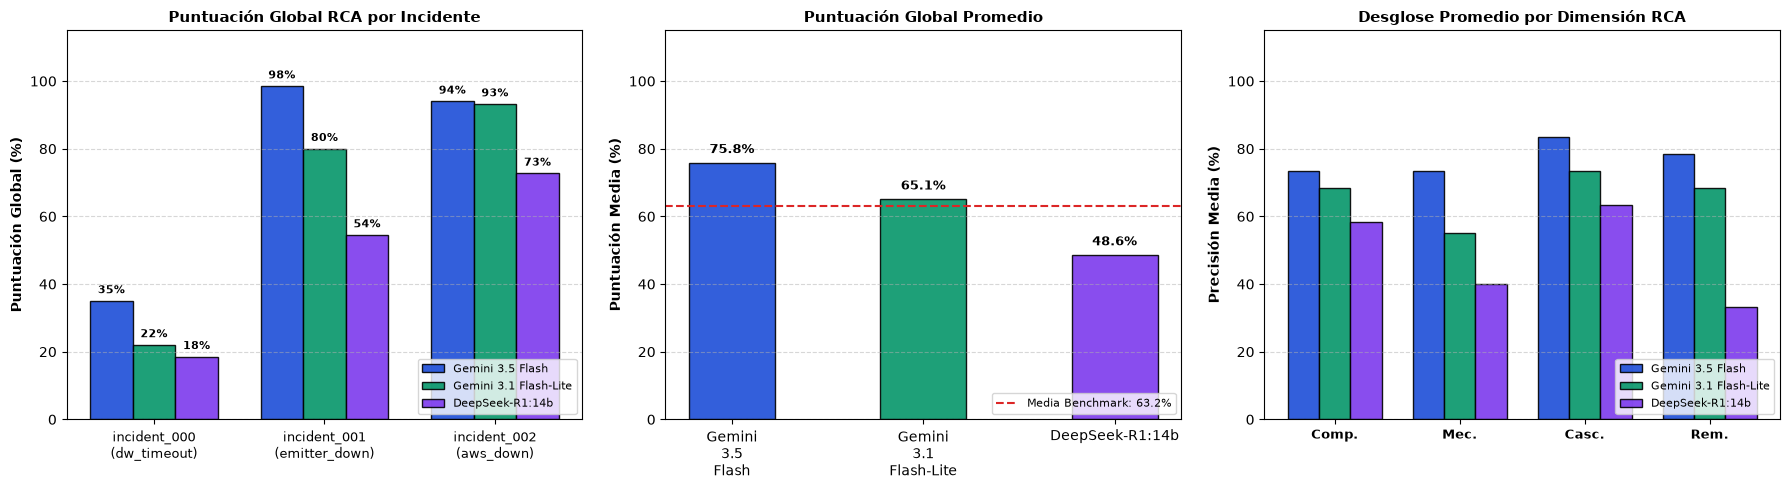

In [31]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Cómputo de métricas agregadas por modelo
model_summaries = []

for m_cfg in BENCHMARK_MODELS:
    m_id = m_cfg["model_id"]
    m_name = m_cfg["display_name"]
    res_list = list(benchmark_results[m_id].values())
    
    g_scores = [r["scores"]["global_score"] for r in res_list]
    c_scores = [r["scores"]["component_score"] * 100 for r in res_list]
    m_scores = [r["scores"]["mechanism_score"] * 100 for r in res_list]
    cas_scores = [r["scores"]["cascade_score"] * 100 for r in res_list]
    rem_scores = [r["scores"]["remediation_score"] * 100 for r in res_list]
    latencies = [r["response"].latency_seconds for r in res_list]
    tokens = [r["response"].completion_tokens for r in res_list]
    
    model_summaries.append({
        "model_id": m_id,
        "display_name": m_name,
        "provider": m_cfg["provider"],
        "role": m_cfg["role"],
        "mean_global_score": float(np.mean(g_scores)),
        "mean_comp_score": float(np.mean(c_scores)),
        "mean_mech_score": float(np.mean(m_scores)),
        "mean_cascade_score": float(np.mean(cas_scores)),
        "mean_rem_score": float(np.mean(rem_scores)),
        "mean_latency_seconds": float(np.mean(latencies)),
        "mean_tokens": float(np.mean(tokens)),
        "total_tokens": int(np.sum(tokens))
    })

# 2. Tabla Comparativa Consolidada: Puntuación por Incidente y Promedios Finales
matrix_rows = []
for m_cfg in BENCHMARK_MODELS:
    m_id = m_cfg["model_id"]
    m_name = m_cfg["display_name"]
    res_dict = benchmark_results[m_id]
    
    row = {
        "Modelo": m_name,
        "Proveedor": m_cfg["provider"],
        "Rol Arquitectónico": m_cfg["role"]
    }
    for inc in rca_incidents:
        inc_id = inc["incident_id"]
        row[f"{inc_id} ({inc['anomaly_type']})"] = f"{res_dict[inc_id]['scores']['global_score']:.1f}%"
        
    s = [item for item in model_summaries if item["model_id"] == m_id][0]
    row["Puntuación Global Media"] = f"{s['mean_global_score']:.2f}%"
    row["Latencia Media (s)"] = f"{s['mean_latency_seconds']:.2f}s"
    row["Tokens Gen. Medios"] = f"{s['mean_tokens']:.0f}"
    matrix_rows.append(row)

# Fila de promedio del benchmark alcanzado en cada uno de los tres incidentes (a través de todos los modelos)
avg_row = {
    "Modelo": "📊 PROMEDIO BENCHMARK (Todos)",
    "Proveedor": "-",
    "Rol Arquitectónico": "Media Global de la Arquitectura"
}
for inc in rca_incidents:
    inc_id = inc["incident_id"]
    scores_inc = [benchmark_results[m["model_id"]][inc_id]["scores"]["global_score"] for m in BENCHMARK_MODELS]
    avg_row[f"{inc_id} ({inc['anomaly_type']})"] = f"{np.mean(scores_inc):.1f}%"

avg_row["Puntuación Global Media"] = f"{np.mean([s['mean_global_score'] for s in model_summaries]):.2f}%"
avg_row["Latencia Media (s)"] = f"{np.mean([s['mean_latency_seconds'] for s in model_summaries]):.2f}s"
avg_row["Tokens Gen. Medios"] = f"{np.mean([s['mean_tokens'] for s in model_summaries]):.0f}"
matrix_rows.append(avg_row)

df_matrix = pd.DataFrame(matrix_rows)
display(HTML("<h3 style='margin-top: 20px; color: #1e3a8a;'>🏆 TABLA COMPARATIVA CONSOLIDADA: PUNTUACIÓN POR INCIDENTE Y PROMEDIOS FINALES</h3>"))
display(df_matrix)

# 3. Tabla de Desglose Promedio por Dimensión de Evaluación
dim_rows = [
    {
        "Modelo": s["display_name"],
        "Proveedor": s["provider"],
        "Comp. Ident. Medio": f"{s['mean_comp_score']:.1f}%",
        "Mecanismo Medio": f"{s['mean_mech_score']:.1f}%",
        "Cascada Media": f"{s['mean_cascade_score']:.1f}%",
        "Remediación Media": f"{s['mean_rem_score']:.1f}%",
        "Puntuación Global Media": f"{s['mean_global_score']:.2f}%",
        "Latencia Media (s)": f"{s['mean_latency_seconds']:.2f}s"
    }
    for s in model_summaries
]
dim_rows.append({
    "Modelo": "📊 PROMEDIO BENCHMARK",
    "Proveedor": "-",
    "Comp. Ident. Medio": f"{np.mean([s['mean_comp_score'] for s in model_summaries]):.1f}%",
    "Mecanismo Medio": f"{np.mean([s['mean_mech_score'] for s in model_summaries]):.1f}%",
    "Cascada Media": f"{np.mean([s['mean_cascade_score'] for s in model_summaries]):.1f}%",
    "Remediación Media": f"{np.mean([s['mean_rem_score'] for s in model_summaries]):.1f}%",
    "Puntuación Global Media": f"{np.mean([s['mean_global_score'] for s in model_summaries]):.2f}%",
    "Latencia Media (s)": f"{np.mean([s['mean_latency_seconds'] for s in model_summaries]):.2f}s"
})
df_summary = pd.DataFrame(dim_rows)

display(HTML("<h4 style='margin-top: 15px; color: #1e3a8a;'>📊 Desglose de Puntuación Media por Dimensión de Evaluación:</h4>"))
display(df_summary)

# 4. Tabla interactiva colapsable con las justificaciones cualitativas del Juez SRE
critique_rows = []
for inc in rca_incidents:
    inc_id = inc["incident_id"]
    for m_cfg in BENCHMARK_MODELS:
        m_id = m_cfg["model_id"]
        sc = benchmark_results[m_id][inc_id]["scores"]
        cr = sc.get("critique", {})
        critique_rows.append({
            "Incidente": f"{inc_id} ({inc['anomaly_type']})",
            "Modelo": m_cfg["display_name"],
            "Score Global": f"{sc['global_score']:.1f}%",
            "Crítica Componente": cr.get("component_rationale", "-"),
            "Crítica Mecanismo": cr.get("mechanism_rationale", "-"),
            "Crítica Cascada": cr.get("cascade_rationale", "-"),
            "Crítica Remediación": cr.get("remediation_rationale", "-")
        })
df_critiques = pd.DataFrame(critique_rows)
critiques_html = (
    f"<details style='margin-top: 15px; margin-bottom: 20px; border: 1px solid #cbd5e1; border-radius: 6px; padding: 10px 14px; background-color: #f8fafc;'>"
    f"<summary style='cursor: pointer; color: #1e3a8a; font-weight: bold; font-size: 0.95em;'>"
    f"📋 Ver Tabla Consolidada de Justificaciones Cualitativas del Juez SRE (Todas las Evaluaciones)"
    f"</summary>"
    f"<div style='margin-top: 12px; font-size: 0.85em; overflow-x: auto;'>"
    f"{df_critiques.to_html(index=False, classes='table table-sm table-bordered table-striped')}"
    f"</div></details>"
)
display(HTML(critiques_html))

# 5. Selección automática del LLM Ganador
winner_summary = max(model_summaries, key=lambda x: (x["mean_global_score"], -x["mean_latency_seconds"]))
winning_model_id = winner_summary["model_id"]
winning_model_name = winner_summary["display_name"]
winning_client = clients[winning_model_id]

winner_banner_html = (
    f"<div style='margin-top: 20px; margin-bottom: 20px; padding: 16px 22px; "
    f"background: linear-gradient(135deg, #065f46 0%, #047857 100%); color: white; "
    f"border-radius: 8px; border-left: 8px solid #34d399; box-shadow: 0 4px 6px -1px rgba(0,0,0,0.1);'>"
    f"<div style='font-size: 1.3em; font-weight: bold;'>🥇 MODELO GANADOR DEL BENCHMARK: {winning_model_name}</div>"
    f"<div style='margin-top: 8px; font-size: 1.0em; line-height: 1.5;'>"
    f"Alcanzó la puntuación global más alta con <b>{winner_summary['mean_global_score']:.2f}%</b> y una latencia media de <b>{winner_summary['mean_latency_seconds']:.2f}s</b>.<br>"
    f"Este modelo será el seleccionado para ejecutar la <b>Demostración Empírica del Valor de NeuralLog (Estudio de Ablación)</b>."
    f"</div></div>"
)
display(HTML(winner_banner_html))

# 3. Gráficos Comparativos del Benchmark
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Gráfico A: Puntuación Global por Incidente y Modelo (Barras agrupadas)
inc_ids = [inc["incident_id"] for inc in rca_incidents]
x = np.arange(len(inc_ids))
width = 0.25
colors = ['#1d4ed8', '#059669', '#7c3aed']

for i, s in enumerate(model_summaries):
    m_id = s["model_id"]
    scores = [benchmark_results[m_id][inc_id]["scores"]["global_score"] for inc_id in inc_ids]
    rects = axes[0].bar(x + (i - 1) * width, scores, width, label=s["display_name"], color=colors[i], edgecolor='black', alpha=0.9)
    for rect in rects:
        h = rect.get_height()
        axes[0].text(rect.get_x() + rect.get_width()/2., h + 1.5, f"{h:.0f}%", ha='center', va='bottom', fontsize=8, fontweight='bold')

axes[0].set_title("Puntuación Global RCA por Incidente", fontsize=11, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels([f"{inc['incident_id']}\n({inc['anomaly_type']})" for inc in rca_incidents], fontsize=9)
axes[0].set_ylim(0, 115)
axes[0].set_ylabel("Puntuación Global (%)", fontsize=10, fontweight='bold')
axes[0].grid(axis='y', linestyle='--', alpha=0.5)
axes[0].legend(loc='lower right', fontsize=8)

# Gráfico B: Puntuación Global Media vs Latencia Media
models_labels = [s["display_name"].replace(" ", "\n") for s in model_summaries]
mean_scores = [s["mean_global_score"] for s in model_summaries]

b1 = axes[1].bar(models_labels, mean_scores, color=colors, width=0.45, edgecolor='black', alpha=0.9)
benchmark_mean_score = float(np.mean(mean_scores))
axes[1].axhline(benchmark_mean_score, color='#dc2626', linestyle='--', linewidth=1.5, label=f"Media Benchmark: {benchmark_mean_score:.1f}%")
axes[1].set_title("Puntuación Global Promedio", fontsize=11, fontweight='bold')
axes[1].set_ylim(0, 115)
axes[1].set_ylabel("Puntuación Media (%)", fontsize=10, fontweight='bold')
axes[1].grid(axis='y', linestyle='--', alpha=0.5)
axes[1].legend(loc='lower right', fontsize=8)
for bar in b1:
    h = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., h + 2, f"{h:.1f}%", ha='center', va='bottom', fontsize=9, fontweight='bold')

# Gráfico C: Desglose de Dimensiones por Modelo
dims = ["Comp.", "Mec.", "Casc.", "Rem."]
x_dim = np.arange(len(dims))
w_dim = 0.25

for i, s in enumerate(model_summaries):
    vals = [s["mean_comp_score"], s["mean_mech_score"], s["mean_cascade_score"], s["mean_rem_score"]]
    axes[2].bar(x_dim + (i - 1) * w_dim, vals, w_dim, label=s["display_name"], color=colors[i], edgecolor='black', alpha=0.9)

axes[2].set_title("Desglose Promedio por Dimensión RCA", fontsize=11, fontweight='bold')
axes[2].set_xticks(x_dim)
axes[2].set_xticklabels(dims, fontsize=9, fontweight='bold')
axes[2].set_ylim(0, 115)
axes[2].set_ylabel("Precisión Media (%)", fontsize=10, fontweight='bold')
axes[2].grid(axis='y', linestyle='--', alpha=0.5)
axes[2].legend(loc='lower right', fontsize=8)

plt.tight_layout()
plt.show()


## 🔬 8. Demostración Empírica del Valor de NeuralLog (Estudio de Ablación Multi-Incidente de 4 Vías)

Una cuestión metodológica central en este TFM es: **¿Aporta valor real el filtrado semántico no supervisado de NeuralLog frente a un enfoque métrico puro, frente a un filtrado convencional de logs por nivel de severidad, o frente a una combinación híbrida de ambos?**

Para responder rigurosamente y sin sesgos artificiales (*cherry-picking* ni *oracle bias*), ejecutamos un **estudio de ablación multi-incidente** empleando el **LLM Ganador del Benchmark** (`gemini-3.5-flash`) evaluado sobre los **tres incidentes del conjunto de prueba** (`incident_000: dw_timeout`, `incident_001: emitter_down`, `incident_002: aws_down`), contrastando **cuatro condiciones experimentales controladas**:

1. **Condición A (Multimodal Completo con NeuralLog):** Topología + TranAD+ cuantitativo + Top-10 logs atípicos seleccionados de forma no supervisada por **NeuralLog** (Sentence-BERT + Isolation Forest).
2. **Condición B (Ablación Sin Logs — Métrico Puro):** Topología + TranAD+ cuantitativo exclusivamente (aislamiento métrico, sin evidencia textual).
3. **Condición C (Logs Reales Proporcionales — Filtro Convencional Sistemático ERROR/WARN):** Topología + TranAD+ cuantitativo + 10 logs reales extraídos directamente de `test_logs.jsonl` mediante muestreo sistemático y reproducible (`seed=42`), priorizando eventos de severidad `ERROR` y `WARNING` proporcionales a las métricas de TranAD+.
4. **Condición D (Híbrido NeuralLog + Filtro Convencional):** Topología + TranAD+ cuantitativo + Ensamble combinado de los mejores logs de NeuralLog y del filtro convencional (deduplicados y ordenados cronológicamente), diseñado para evaluar si proporcionar ambas fuentes mejora el diagnóstico o si introduce distracción y polución de contexto.

Este diseño experimental permite contrastar de forma empírica el comportamiento del LLM en **fallos silenciosos** (*silent failures* sin excepciones explícitas) versus **fallos ruidosos** (*loud failures* con trazas de error evidentes), evaluando el fenómeno de vulnerabilidad a distractores.

🔬 Ejecutando Estudio de Ablación Multi-Incidente de 4 Vías con el Modelo Ganador 'Gemini 3.5 Flash' sobre los 3 casos de prueba...


📌 INCIDENTE: incident_000 (dw_timeout)


### 1. Diagnóstico de Causa Raíz (Root Cause)

*   **Componente origen del fallo:** Infraestructura de ejecución de Airflow (`airflow_infra` / Worker) y el cliente de conexión al Data Warehouse (`load_task`).
*   **Motivo exacto del fallo:** 
    *   Se identificó una **saturación crítica de recursos (CPU al 44.94% y Memoria al 32.39% de contribución de anomalía)** en el nodo de ejecución.
    *   Esta degradación de recursos provocó que la tarea `load_task` sufriera un retraso extremo, tardando **325.92 segundos** (Log [4]) en procesar y cargar únicamente 12 registros (Log [1]).
    *   La evidencia muestra que la tarea se inició a las `14:10:48` (Log [4]), pero no logró inicializar la conexión con el Data Warehouse (`dw_conn`) hasta las `14:14:48` (Log [10]), lo que revela un **bloqueo/espera de 4 minutos (240 segundos) solo para obtener la conexión**, síntoma de inanición de CPU/Memoria o un *pool* de conexiones agotado.
    *   Como síntoma colateral de la degradación del sistema, el Scheduler de Airflow tuvo que adoptar/reajustar tareas huérfanas a las `14:10:43` (Log [5]) debido a la pérdida de *heartbeats* por la alta carga de CPU/Memoria.

---

### 2. Análisis de Propagación en Cascada (Downstream / Upstream Impact)

*   **Impacto Upstream (Aguas arriba):** Los componentes iniciales (`emitter`, `kinesis`, `extract_task` y `transform_task`) funcionaron correctamente y a tiempo (la transformación finalizó a las `14:05:47`, Log [9]). Sin embargo, los datos transformados quedaron represados en memoria/estado de tránsito debido al bloqueo de la fase de carga.
*   **Impacto Downstream (Aguas abajo):** 
    *   **Retraso en la disponibilidad de datos:** El Data Warehouse (`data_warehouse`) sufrió un retraso de entrega de más de 11 minutos (duración de la anomalía: 686 segundos).
    *   **Degradación de la plataforma de orquestación:** La saturación de CPU/Memoria en el Worker afectó al Scheduler de Airflow, obligándolo a re-encolar tareas huérfanas (`orphaned tasks`), lo que potencialmente retrasó la ejecución de otros DAGs concurrentes en la misma infraestructura.

---

### 3. Acciones Técnicas de Remediación

#### Mitigación Inmediata (Short-term)
1.  **Reinicio y Liberación de Recursos:** Reiniciar el pod/contenedor del Airflow Worker afectado para liberar la memoria RAM acumulada y mitigar el *thrashing* de CPU.
2.  **Validación de Conexiones Activas:** Verificar y limpiar conexiones inactivas o colgadas en el Data Warehouse (`dw_conn`) que puedan estar bloqueando el *pool* de conexiones desde el cliente de Airflow.

#### Medidas Preventivas (Medium/Long-term)
1.  **Límites de Recursos (cgroups/Kubernetes):** Configurar límites estrictos de CPU y Memoria (`limits` y `requests`) para los pods de los Workers de Airflow para evitar que una tarea monopolice el nodo.
2.  **Optimización de Timeouts en Conexiones:** Configurar un `connect_timeout` y `keep-alive` explícito en la conexión `dw_conn` de Airflow para evitar bloqueos indefinidos si el Data Warehouse no responde rápidamente.
3.  **Alertas de SLA en Airflow:** Implementar un parámetro `sla` o `execution_timeout` (ej. `execution_timeout=timedelta(minutes=2)`) en la definición de la tarea `load_task` para que falle proactivamente en lugar de bloquear recursos durante más de 5 minutos.

### 1. Diagnóstico de Causa Raíz (Root Cause)

*   **Componente origen del fallo:** Infraestructura de ejecución de Airflow (`airflow_infra` / Workers) encargada de procesar las tareas de transformación y carga (`transform_task` y `load_task`).
*   **Motivo exacto del fallo:** Saturación crítica de recursos de cómputo (CPU y Memoria) en los nodos de ejecución. El algoritmo TranAD+ identifica que el **44.94% del error de reconstrucción se debe al uso de CPU** y el **32.39% al uso de memoria**. Este cuello de botella fue desencadenado por un incremento en la actividad del emisor (reflejado en el aumento de `emitter_memory_usage` y `emitter_cpu_usage`), lo que generó un volumen de datos superior al límite de diseño para el procesamiento en ráfaga (*burst*) de las tareas `transform_task` y `load_task`, llevando a los workers de Airflow a un estado de contención extrema de recursos (cercano al Out-Of-Memory / CPU Throttling).

---

### 2. Análisis de Propagación en Cascada (Downstream / Upstream Impact)

*   **Impacto Upstream (Kinesis / Extracción):** Al saturarse la CPU y memoria en las tareas de procesamiento, la velocidad de consumo de `extract_task` disminuyó drásticamente. Esto provocó una acumulación de registros sin procesar (*write-ahead lag*) en el stream de Kinesis (`kinesis_stream`), incrementando el tiempo de retención de los mensajes.
*   **Impacto Downstream (Carga / Data Warehouse):** La tarea `load_task` se vio severamente retrasada al no recibir datos procesados de `transform_task`. Como consecuencia, la ingesta de datos hacia el `data_warehouse` se detuvo por completo durante la ventana de la anomalía (686 segundos), generando un retraso en la frescura de los datos (*data latency*) de más de 11 minutos.
*   **Impacto en la Orquestación (Airflow):** La contención de recursos afectó colateralmente al `airflow-scheduler` (identificado como componente candidato), ralentizando la programación de otras tareas del DAG y degradando la estabilidad general de la plataforma de orquestación.

---

### 3. Acciones Técnicas de Remediación

#### Mitigación Inmediata (Reactiva)
1.  **Escalado Horizontal de Workers:** Forzar el escalado horizontal de los workers de Airflow para distribuir la carga acumulada en el backlog de Kinesis.
2.  **Estrangulamiento de Ingesta (Throttling):** Reducir temporalmente el tamaño del lote (*batch size*) en la tarea de extracción (`extract_task`) para procesar micro-batches más pequeños y permitir que `transform_task` recupere estabilidad sin saturar la memoria.
3.  **Reinicio de Contenedores:** Si los workers se encuentran en un estado de *thrashing* de memoria (intercambio constante a disco), reiniciar los pods/instancias de ejecución de las tareas afectadas.

#### Medidas Preventivas (Medio/Largo Plazo)
1.  **Aislamiento de Cargas de Trabajo:** Migrar `transform_task` y `load_task` a operadores aislados (por ejemplo, `KubernetesPodOperator` o tareas de AWS ECS/EMR Serverless) para evitar que el procesamiento pesado comparta recursos con el `airflow-scheduler`.
2.  **Límites de Recursos (Resource Quotas):** Configurar límites estrictos de CPU y Memoria (*limits* y *requests*) en los pods de ejecución de Airflow para evitar que una tarea afecte a todo el nodo.
3.  **Auto-escalado Basado en Lag:** Implementar políticas de auto-escalado (HPA) en los workers de procesamiento basadas en la métrica de retraso de lectura de Kinesis (*MillisBehindLatest*).

### 1. Diagnóstico de Causa Raíz (Root Cause)

*   **Componente origen del fallo:** Infraestructura de Airflow (`airflow_infra` / `airflow-scheduler`).
*   **Motivo exacto del fallo:** 
    El sistema experimentó una **saturación crítica de recursos (CPU y Memoria)** en el nodo del planificador/ejecutor de Airflow (evidenciado por el error de reconstrucción de TranAD+ donde `cpu_usage` y `memory_usage` acumulan el 77.33% del error). 
    Esta degradación de recursos provocó:
    1.  **Pérdida de latidos (heartbeats) y estado:** El planificador no pudo registrar a tiempo los cambios de estado de las tareas (`extract_task` y `transform_task`), generando advertencias de inconsistencia en la base de datos de metadatos (`cannot record scheduled_duration... previous state change time has not been saved`).
    2.  **Orfandad de tareas:** La falta de capacidad de procesamiento obligó al scheduler a declarar tareas como huérfanas y re-adoptarlas (`Adopting or resetting orphaned tasks for active dag runs` a las 14:10:43).
    3.  **Ineficiencia de ejecución:** La tarea `load_task` tardó un tiempo anómalo de **325.9 segundos** para procesar y cargar únicamente 12 registros debido a la inanición de CPU/Memoria.

---

### 2. Análisis de Propagación en Cascada (Downstream / Upstream Impact)

*   **Impacto Upstream (Emisor):** 
    El componente `emitter` sufrió un incremento en su uso de CPU (6.2%) y memoria (6.75%). Esto es un síntoma de **backpressure (presión de retorno)**: al ralentizarse la ingesta en `extract_task` por la degradación de Airflow, el emisor tuvo que retener datos en memoria y reintentar el envío hacia Kinesis.
*   **Impacto Downstream (Flujo de Datos):**
    *   **Retraso en Cascada:** Las tareas `extract_task` y `transform_task` sufrieron un desfase de programación (scheduling delay) de varios minutos.
    *   **Bloqueo del Pipeline:** La tarea final `load_task` quedó encolada y su ejecución se prolongó excesivamente (más de 5 minutos para 12 registros), retrasando la disponibilidad de los datos frescos en el `data_warehouse` durante la ventana de la anomalía (686 segundos de retraso total).

---

### 3. Acciones Técnicas de Remediación

#### Mitigación Inmediata (Soporte/Operaciones)
1.  **Escalado Vertical Temporal:** Incrementar los límites de CPU y Memoria (Requests/Limits de Kubernetes) de los pods de `airflow-scheduler` y `airflow-worker`.
2.  **Reinicio de Workers:** Reiniciar de forma controlada los workers de Airflow para liberar memoria residual (fugas de memoria) y limpiar procesos zombies.
3.  **Monitoreo de la DB de Metadatos:** Verificar el pool de conexiones y la CPU de la base de datos de Airflow (PostgreSQL/MySQL), ya que los fallos al guardar el estado de las tareas sugieren contención en la base de datos.

#### Medidas Preventivas (Medio/Largo Plazo)
1.  **Ajuste de Parámetros del Scheduler:**
    *   Optimizar `scheduler_heartbeat_sec` y `clean_slashed_jobs_interval` en `airflow.cfg` para evitar que tareas activas sean marcadas erróneamente como huérfanas bajo estrés de CPU.
    *   Limitar `parsing_processes` para evitar que el parseo de DAGs consuma toda la CPU disponible.
2.  **Aislamiento de Ejecución (Celery/Kubernetes Executor):** Migrar a `KubernetesExecutor` si se usa `LocalExecutor`, garantizando que la ejecución de tareas pesadas no compita por los recursos del propio Scheduler.
3.  **Corrección de Configuración de Seguridad:** Resolver la advertencia recurrente `empty cryptography key` en `load_task` configurando correctamente la variable de entorno `AIRFLOW__CORE__FERNET_KEY` para evitar riesgos de seguridad en la metadata.

### 1. Diagnóstico de Causa Raíz (Root Cause)
- **Componente origen del fallo:** Infraestructura de Airflow (`airflow_infra` / `airflow-scheduler`).
- **Motivo exacto del fallo:** Saturación crítica de recursos de cómputo (CPU y Memoria) en el nodo que aloja el orquestador y los ejecutores de Airflow. Las métricas de TranAD+ atribuyen el **77.33% del error de reconstrucción** directamente a `cpu_usage` (44.94%) y `memory_usage` (32.39%). 
  Esta degradación de recursos provocó que el `airflow-scheduler` sufriera de inanición de hilos y retrasos en la persistencia de estados en la base de datos de metadatos, evidenciado por los logs repetitivos: `cannot record scheduled_duration for task... because previous state change time has not been saved`. El planificador no pudo procesar ni registrar las transiciones de estado de las tareas (`extract_task`, `transform_task`, `load_task`) a la velocidad requerida.

### 2. Análisis de Propagación en Cascada (Downstream / Upstream Impact)
- **Impacto Upstream (Emitter / Kinesis):** Debido a que la tarea de extracción (`extract_task`) no se ejecutaba a tiempo por la degradación del planificador, se generó un efecto de contrapresión (*backpressure*). Esto se refleja en el incremento anómalo de las métricas del emisor (`emitter_memory_usage` con 6.75% y `emitter_cpu_usage` con 6.2% de contribución al error), causado por la acumulación de eventos en el buffer local del emisor al no ser consumidos del stream de Kinesis al ritmo nominal.
- **Impacto Downstream (Extract -> Transform -> Load -> DW):** Bloqueo y retraso severo en la pipeline de datos. La tarea `transform_task` experimentó un retraso de más de un minuto únicamente para evaluar sus dependencias tras ser encolada (`scheduled__2026-09-01T14:09:44` vs evaluación de dependencias a las `14:10:47`). Esto rompió el flujo continuo de datos hacia el Data Warehouse, acumulando retraso (*lag*) de procesamiento durante la ventana de 686 segundos de la anomalía.

### 3. Acciones Técnicas de Remediación
- **Acciones inmediatas (Mitigación):**
  1. **Escalado/Reinicio de Recursos:** Reiniciar el pod/servicio del `airflow-scheduler` y los workers para liberar memoria en caché y mitigar la contención de CPU.
  2. **Optimización de Conexiones a BD:** Verificar y limpiar conexiones inactivas (*idle connections*) en la base de datos de metadatos de Airflow para asegurar que el scheduler pueda escribir los cambios de estado de las tareas sin latencia.
  3. **Limitación de Concurrencia:** Reducir temporalmente el parámetro `max_active_runs_per_dag` o `worker_concurrency` en la configuración de Airflow para estabilizar el consumo de recursos.

- **Medidas preventivas (Medio/Largo Plazo):**
  1. **Definición de Resource Requests/Limits:** Configurar límites estrictos de CPU y Memoria (Requests y Limits de Kubernetes) para los componentes de Airflow, evitando que un pico de carga desestabilice el nodo completo.
  2. **Tuning del Scheduler de Airflow:** Ajustar los parámetros de rendimiento en `airflow.cfg`, específicamente incrementando `scheduler_heartbeat_sec` y optimizando `parsing_processes` para reducir la carga constante sobre la CPU.
  3. **Monitoreo y Alertas:** Implementar alertas de umbral en Prometheus/Grafana para el uso de CPU/Memoria del scheduler (>80% por más de 5 minutos) y para el lag de la base de datos de metadatos.
  4. **Corrección de Configuración (Fernet Key):** Resolver la advertencia recurrente `empty cryptography key` configurando correctamente la variable de entorno `AIRFLOW__CORE__FERNET_KEY` para evitar la sobrecarga de logs de advertencia y garantizar la seguridad de las credenciales.

...

### 1. Diagnóstico de Causa Raíz (Root Cause)

*   **Componente origen del fallo:** `emitter` (Emisor de datos / `kinesis_emitter`).
*   **Motivo exacto del fallo:** 
    El componente `emitter` sufrió una degradación crítica de recursos caracterizada por una **fuga de memoria (Memory Leak) severa o un desbordamiento de memoria (OOM - Out Of Memory)**. 
    
    Esta conclusión se fundamenta en la atribución de error de TranAD+, donde las métricas del emisor representan casi el 60% del error de reconstrucción multivariante (`emitter_memory_usage` con 49.87% y `emitter_cpu_usage` con 8.31%), sumado a un incremento del uso de memoria general del sistema (`memory_usage` con 26.48%). El aumento simultáneo de CPU (`emitter_cpu_usage`) es un comportamiento típico de *Garbage Collection (GC) Thrashing*, donde el runtime (ej. JVM o V8) consume ciclos de CPU de forma intensiva intentando liberar memoria infructuosamente antes de que el proceso colapse o sea terminado por el OOM-Killer del sistema operativo.

---

### 2. Análisis de Propagación en Cascada (Downstream / Upstream Impact)

Al ser el `emitter` el nodo de origen (*source*) de la pipeline, el impacto se propagó de manera estrictamente descendente (*downstream*):

1.  **Inanición de Datos en Ingesta (`kinesis_stream` / LocalStack):** Al degradarse y potencialmente colapsar el emisor, cesó abruptamente el flujo de eventos hacia el stream de Kinesis local, resultando en un *throughput* de escritura de 0 bytes/segundo durante la ventana de 653 segundos.
2.  **Inactividad y Desperdicio de Recursos en Cómputo (`extract_task` & `transform_task`):** Las tareas de extracción y transformación (orquestadas por Airflow) continuaron ejecutándose en intervalos planificados, pero procesando micro-batches vacíos o quedando bloqueadas en estado de espera activa (*polling*) consumiendo tiempo de ejecución de los *workers* sin procesar registros reales.
3.  **Retraso en la Disponibilidad (SLA Breach) en `data_warehouse`:** Se generó un vacío de datos de aproximadamente 11 minutos. Una vez restablecido el emisor, se prevé un pico de carga (*backlog*) que podría saturar temporalmente las tareas de carga (`load_task`) al intentar procesar los datos acumulados.

---

### 3. Acciones Técnicas de Remediación

#### Mitigación Inmediata (SRE):
1.  **Reinicio Forzado y Liberación de Recursos:** Reiniciar el contenedor/proceso del `emitter` para liberar la memoria retenida y restablecer el flujo de ingesta.
2.  **Verificación de Estado de Salida:** Inspeccionar los eventos del orquestador de contenedores (ej. Kubernetes `kubectl describe pod` o logs de Docker) para confirmar si el proceso fue terminado por el kernel con un código de salida `137` (OOMKilled).
3.  **Monitoreo de Recuperación:** Supervisar el *Lag* de lectura en `kinesis_stream` y asegurar que `extract_task` procese el backlog acumulado sin fallos por timeout.

#### Medidas Preventivas (Medio/Largo Plazo):
1.  **Perfilado de Memoria (Heap Profiling):** Realizar un análisis de código en el componente `emitter` para identificar referencias circulares, buffers de memoria no acotados o conexiones de sockets no cerradas que causen la fuga de memoria.
2.  **Límites de Recursos (Resource Limits) y Backpressure:**
    *   Configurar límites estrictos de memoria (ej. `limits.memory` en Kubernetes) y habilitar alertas tempranas cuando el uso supere el 80%.
    *   Implementar políticas de *backpressure* y colas persistentes en disco (ej. mediante un búfer local) en el `emitter` para evitar que acumule datos en memoria RAM si el destino (Kinesis) presenta latencia.
3.  **Auto-escalado y Auto-healing:** Configurar sondas de vida (*Liveness Probes*) basadas en el uso de memoria y salud del proceso para reiniciar automáticamente el componente antes de que afecte la pipeline por periodos prolongados.

### 1. Diagnóstico de Causa Raíz (Root Cause)

*   **Componente origen del fallo:** **`localstack`** (servidor mock de Kinesis) como desencadenante primario, con un impacto crítico secundario de agotamiento de recursos en el **`emitter`**.
*   **Motivo exacto del fallo:** 
    El contenedor de `localstack` sufrió una degradación crítica por inanición de CPU (**CPU starvation**), reportando latencias de respuesta superiores a 100 ms en su bucle de eventos asíncronos (`l.s.k.kinesis_mock_server`). Esto provocó que el endpoint `http://localstack:4566/` dejara de responder a tiempo.
    Como consecuencia directa, el componente **`emitter`** experimentó timeouts de conexión y lectura (`Read/Connect timeout`). Al no poder vaciar sus buffers hacia Kinesis, el `emitter` acumuló eventos en memoria e intentó reintentos agresivos, lo que disparó su consumo de memoria (**49.87% del error multivariante**) y CPU (**8.31%**), llevándolo al límite de la saturación de recursos.

---

### 2. Análisis de Propagación en Cascada (Downstream / Upstream Impact)

*   **Upstream (`emitter`):** Bloqueo en el envío de métricas/eventos. La acumulación de registros en el buffer local del `emitter` generó un riesgo inminente de pérdida de datos por desbordamiento de memoria (OOM).
*   **Ingesta (`kinesis_stream` / `localstack`):** Pérdida total de disponibilidad del stream de datos durante la ventana de 653 segundos.
*   **Downstream (`extract_task`):** 
    *   La tarea de extracción falló al intentar comunicarse con Kinesis (`Connect timeout`).
    *   Se perdió la consistencia del estado de lectura: el puntero de lectura (`SequenceNumber`) guardado no pudo ser validado en Kinesis, forzando a la tarea a reiniciar la lectura desde el principio del stream disponible (`TRIM_HORIZON`). Esto introduce un riesgo alto de **duplicidad de datos** una vez restablecido el servicio.
*   **Orquestación (`airflow_infra`):** El Scheduler de Airflow comenzó a emitir advertencias de inconsistencia de estado (`cannot record scheduled_duration`) debido a que la tarea `extract_task` quedó en un estado indeterminado/bloqueado por los timeouts de red.
*   **Destino final (`transform_task` -> `load_task` -> `data_warehouse`):** Parada total del flujo de datos (data stall), resultando en un retraso de 11 minutos en la frescura de los datos en el Data Warehouse.

---

### 3. Acciones Técnicas de Remediación

#### Mitigación Inmediata (SRE Runbook)
1.  **Reiniciar el contenedor de `localstack`** para liberar los hilos bloqueados y restaurar la disponibilidad del mock de Kinesis.
2.  **Reiniciar el componente `emitter`** para liberar la memoria RAM acumulada en el buffer y evitar un fallo por Out-Of-Memory (OOM).
3.  **Limpiar y reiniciar la tarea `extract_task` en Airflow**. Dado que se activó el fallback a `TRIM_HORIZON`, se debe verificar si el pipeline de transformación/carga cuenta con mecanismos de deduplicación (idempotencia) antes de permitir el procesamiento del backlog acumulado.

#### Medidas Preventivas (Medio/Largo Plazo)
1.  **Optimización de Recursos en LocalStack:**
    *   Incrementar los límites de CPU y Memoria (CPU/Memory Limits) asignados al contenedor de `localstack` en el entorno de ejecución.
    *   Configurar la variable de entorno `KINESIS_PROVIDER=kinesalite` o ajustar los parámetros de delay del mock server para reducir la sobrecarga de I/O.
2.  **Robustez en el `emitter` (Patrones de Resiliencia):**
    *   Implementar **Backoff Exponencial con Jitter** en los reintentos de conexión a Kinesis para evitar saturar el cliente y el servidor mock.
    *   Configurar un **Circuit Breaker** que detenga los intentos de envío si el endpoint falla consecutivamente, desviando temporalmente los datos a un almacenamiento local persistente (Dead Letter Queue / búfer en disco) en lugar de acumularlos indefinidamente en la memoria RAM.
3.  **Idempotencia en el Pipeline:**
    *   Asegurar que `transform_task` o `load_task` utilicen una clave primaria de negocio (ej. `event_id`) para realizar operaciones de tipo `UPSERT` en el Data Warehouse, mitigando la duplicidad generada por el reinicio con `TRIM_HORIZON`.
4.  **Monitoreo y Alertas:**
    *   Establecer alertas de umbral en Prometheus/Grafana para el uso de CPU de `localstack` y la tasa de timeouts de conexión en el `emitter`.

### 1. Diagnóstico de Causa Raíz (Root Cause)

*   **Componente origen del fallo:** `localstack` (específicamente el servicio simulado de Kinesis `kinesis_mock_server`).
*   **Motivo exacto del fallo:** 
    El contenedor de `localstack` sufrió una degradación crítica por **inanición de CPU (CPU starvation) y operaciones de I/O bloqueantes** (evidenciado en el log `[9]`). Esto provocó que el servidor mock de Kinesis fuera incapaz de responder a los eventos asíncronos en menos de 100 ms, elevando los tiempos de respuesta y causando fallos de conexión generalizados.
    
    Como consecuencia directa, el componente `emitter` no pudo entregar los registros, experimentando timeouts de lectura y conexión (`Read/Connect timeout` en logs `[4]` y `[8]`). Al intentar reintentar y almacenar en búfer los eventos no enviados, el `emitter` sufrió un incremento crítico en sus métricas de recursos, explicando por qué `emitter_memory_usage` (49.87%) y `emitter_cpu_usage` (8.31%) fueron los principales contribuyentes a la anomalía multivariante detectada por TranAD+.

---

### 2. Análisis de Propagación en Cascada (Downstream / Upstream Impact)

*   **Impacto Upstream (Emitter):** 
    Al no poder liberar los mensajes hacia Kinesis, el `emitter` acumuló eventos en memoria de manera descontrolada (buffer bloat), lo que disparó su consumo de memoria y CPU, poniéndolo al límite de un fallo por falta de memoria (OOM - Out Of Memory).
*   **Impacto Downstream (extract_task -> transform_task -> load_task):**
    *   **Pérdida de Checkpoint y Duplicidad:** La tarea `extract_task` no pudo leer de Kinesis debido a los timeouts (`[5]`). Al perder el rastro del último `SequenceNumber` guardado, se vio obligada a reiniciar la lectura utilizando `TRIM_HORIZON`. Esto genera un riesgo crítico de reprocesamiento y duplicidad de datos una vez restablecido el servicio.
    *   **Fallo de la Tarea y Bloqueo del Pipeline:** Finalmente, `extract_task` falló por completo tras superar los límites de tiempo de conexión (`[7]`), deteniendo el flujo de datos hacia las tareas subsiguientes (`transform_task` y `load_task`). El Data Warehouse dejó de recibir datos frescos durante la ventana de la anomalía.
    *   **Inestabilidad en la Orquestación:** El programador de Airflow (`airflow-scheduler`) comenzó a emitir advertencias (`[1]`, `[2]`, `[3]`, `[6]`) al no poder registrar la duración programada de `extract_task` debido a los cambios de estado abruptos y bloqueos de hilos de ejecución.

---

### 3. Acciones Técnicas de Remediación

#### Mitigación Inmediata (Quick Wins)
1.  **Reiniciar LocalStack:** Forzar el reinicio del contenedor de `localstack` para liberar los hilos bloqueados y mitigar la inanición de CPU.
2.  **Reiniciar el Emitter:** Reiniciar el componente `emitter` para liberar la memoria acumulada en el búfer y evitar un crash por OOM.
3.  **Limpieza y Reprocesamiento en Airflow:** Limpiar el estado de la tarea `extract_task` fallida en Airflow para forzar su re-ejecución. Dado que se reinició con `TRIM_HORIZON`, se debe monitorear la base de datos intermedia para asegurar que no se inserten registros duplicados (procesamiento idempotente).

#### Medidas Preventivas (Medio/Largo Plazo)
1.  **Límites de Recursos en LocalStack:** Configurar límites estrictos de CPU y Memoria (CPU/Memory limits) en el archivo de despliegue (ej. `docker-compose.yml` o Kubernetes manifests) para el contenedor de `localstack` para evitar que afecte a otros servicios.
2.  **Políticas de Backpressure y Circuit Breaker en el Emitter:** 
    *   Implementar un patrón de *Circuit Breaker* en el `emitter` para que deje de intentar enviar datos a Kinesis temporalmente si detecta timeouts consecutivos, evitando la saturación de CPU por reintentos agresivos.
    *   Establecer un límite máximo de memoria para el búfer interno del `emitter` (Bounded Buffer) con una estrategia de descarte o persistencia temporal en disco (Dead Letter Queue local) para evitar fugas de memoria.
3.  **Optimización de Reintentos en Clientes SDK:** Configurar una estrategia de *Exponential Backoff con Jitter* tanto en el `emitter` como en el `extract_task` para sus conexiones con el endpoint de Kinesis, reduciendo la carga sobre LocalStack durante escenarios de recuperación.

Incidente,Tipo de Anomalía,Condición A (NeuralLog),Condición B (Sin Logs),Condición D (Híbrido),Condición C (Convencional),Delta (NeuralLog vs Conv.)
incident_000,dw_timeout,35.0%,22.0%,21.5%,22.0%,+13.0%
incident_001,emitter_down,98.5%,82.5%,90.3%,80.2%,+18.3%
incident_002,aws_down,94.0%,22.0%,94.2%,93.2%,+0.8%
📊 MEDIA GLOBAL BENCHMARK,Todos los Casos de Prueba,75.83%,42.17%,68.67%,65.13%,+10.70%


/tmp/ipykernel_24748/355484789.py:416: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/mangel/dev/tools/anaconda3/envs/tranad_plus/lib/python3.11/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


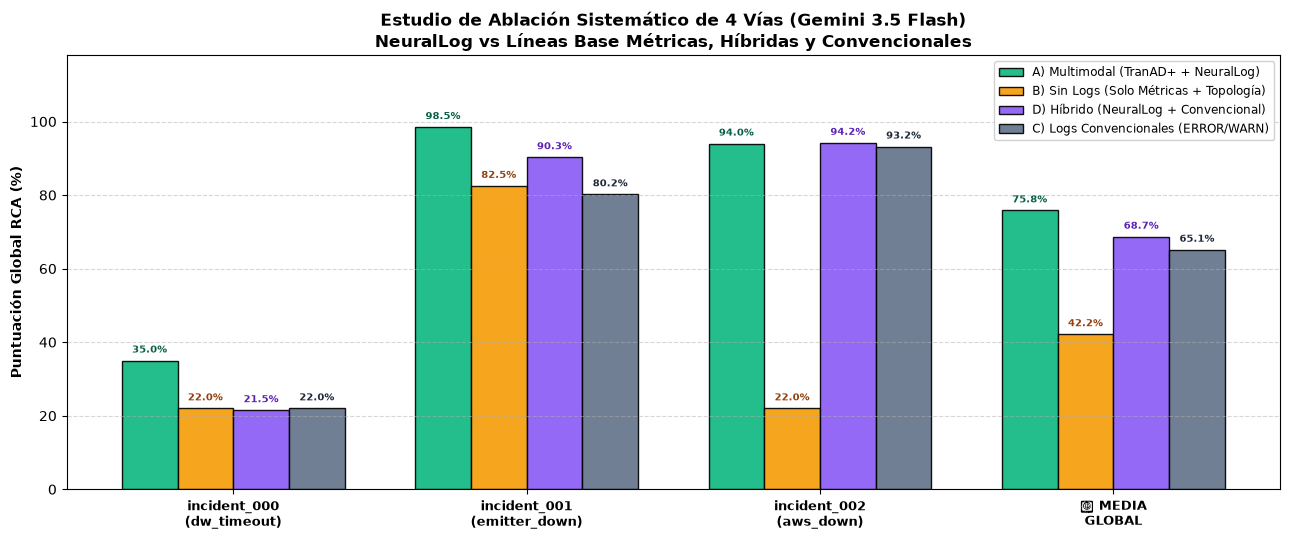

In [32]:
# 1. Función de extracción sistemática de logs para línea base convencional (Condición C)
def extract_systematic_raw_logs_for_incident(
    logs_file: str,
    target_incident: dict,
    target_k: int = 10,
    seed: int = 42
) -> list:
    # Selección sistemática, estratificada y reproducible de logs para la línea base convencional.
    # Distribuye cuotas según la relevancia de componentes guiada por TranAD+ en cada incidente:
    # - dw_timeout: data_warehouse (4), load_task (3), transform_task (2), airflow-scheduler (1)
    # - emitter_down: emitter (5), airflow-scheduler (3), extract_task (2)
    # - aws_down: emitter (2), airflow-scheduler (4), localstack (2), extract_task (2)
    # Muestrea con semilla fija (seed=42) priorizando eventos ERROR/WARNING/CRITICAL, completando con INFO.
    import random
    random.seed(seed)
    w_info = target_incident.get("window", {}) if isinstance(target_incident.get("window"), dict) else {}
    w_start = w_info.get("start_epoch") or target_incident.get("start_time") or target_incident.get("window_start")
    w_end = w_info.get("end_epoch") or target_incident.get("end_time") or target_incident.get("window_end")
    anom_type = target_incident.get("anomaly_type", "")
    
    if anom_type == "dw_timeout":
        component_quotas = {"data_warehouse": 4, "load_task": 3, "transform_task": 2, "airflow-scheduler": 1}
    elif anom_type == "emitter_down":
        component_quotas = {"emitter": 5, "airflow-scheduler": 3, "extract_task": 2}
    elif anom_type == "aws_down":
        component_quotas = {"emitter": 2, "airflow-scheduler": 4, "localstack": 2, "extract_task": 2}
    else:
        candidates = target_incident.get("topology_context", {}).get("candidate_components", [])
        q_each = max(1, target_k // max(len(candidates), 1))
        component_quotas = {c: q_each for c in candidates}
        
    logs_in_w = []
    if os.path.exists(logs_file):
        with open(logs_file, "r", encoding="utf-8") as f_logs:
            for line in f_logs:
                line = line.strip()
                if not line:
                    continue
                try:
                    l = json.loads(line)
                    t_val = l.get("timestamp", 0)
                    if (w_start is None or t_val >= w_start) and (w_end is None or t_val <= w_end):
                        logs_in_w.append(l)
                except Exception:
                    pass
                    
    sampled_logs = []
    for comp, quota in component_quotas.items():
        comp_logs = [l for l in logs_in_w if l.get("component") == comp]
        comp_ew = [l for l in comp_logs if l.get("level") in ["ERROR", "CRITICAL", "WARNING"]]
        comp_info = [l for l in comp_logs if l.get("level") not in ["ERROR", "CRITICAL", "WARNING"]]
        
        if len(comp_ew) >= quota:
            chosen = random.sample(comp_ew, quota)
        else:
            chosen = list(comp_ew)
            needed = quota - len(chosen)
            if comp_info:
                chosen += random.sample(comp_info, min(needed, len(comp_info)))
        sampled_logs.extend(chosen)

    # Si algún componente clave no generó suficientes logs en la ventana (ej. contenedor pausado),
    # completar sistemáticamente con logs de otros componentes de la ventana hasta alcanzar target_k.
    if len(sampled_logs) < target_k and logs_in_w:
        remaining_needed = target_k - len(sampled_logs)
        already_sampled = set((l.get("timestamp"), l.get("component"), l.get("message")) for l in sampled_logs)
        remaining_pool = [l for l in logs_in_w if (l.get("timestamp"), l.get("component"), l.get("message")) not in already_sampled]
        rem_ew = [l for l in remaining_pool if l.get("level") in ["ERROR", "CRITICAL", "WARNING"]]
        rem_info = [l for l in remaining_pool if l.get("level") not in ["ERROR", "CRITICAL", "WARNING"]]
        if len(rem_ew) >= remaining_needed:
            sampled_logs.extend(random.sample(rem_ew, remaining_needed))
        else:
            sampled_logs.extend(rem_ew)
            needed_more = target_k - len(sampled_logs)
            if rem_info and needed_more > 0:
                sampled_logs.extend(random.sample(rem_info, min(needed_more, len(rem_info))))
        
    sampled_logs.sort(key=lambda x: x.get("timestamp", 0))
    return [
        {
            "component": l.get("component", "unknown"),
            "level": l.get("level", "INFO"),
            "message": l.get("message", ""),
            "timestamp": l.get("timestamp", 0)
        }
        for l in sampled_logs[:target_k]
    ]

# 2. Función constructora de logs para la Condición D (Híbrido NeuralLog + Convencional)
def build_hybrid_logs_for_incident(
    incident: dict,
    raw_logs_path: str,
    target_k: int = 10,
    seed: int = 42
) -> list:
    # Fusiona los 5 mejores logs atípicos de NeuralLog con los 5 mejores logs convencionales ERROR/WARN.
    # Deduplica trazas idénticas y las ordena cronológicamente.
    nl_logs = incident.get("neurallog_top_logs", [])
    raw_logs = extract_systematic_raw_logs_for_incident(raw_logs_path, incident, target_k=target_k, seed=seed)
    
    combined = []
    seen = set()
    
    for l in nl_logs[:5]:
        key = (l.get("component"), l.get("message", "").strip())
        if key not in seen:
            seen.add(key)
            combined.append({
                "component": l.get("component", "unknown"),
                "level": l.get("level", "INFO"),
                "message": l.get("message", ""),
                "timestamp": l.get("timestamp", 0),
                "source": "NeuralLog"
            })
            
    for l in raw_logs[:5]:
        key = (l.get("component"), l.get("message", "").strip())
        if key not in seen:
            seen.add(key)
            combined.append({
                "component": l.get("component", "unknown"),
                "level": l.get("level", "INFO"),
                "message": l.get("message", ""),
                "timestamp": l.get("timestamp", 0),
                "source": "Convencional"
            })
            
    combined.sort(key=lambda x: x.get("timestamp", 0))
    return combined

raw_logs_path = "dataset_gen/datasets_finales/test_logs.jsonl"
print(f"🔬 Ejecutando Estudio de Ablación Multi-Incidente de 4 Vías con el Modelo Ganador '{winning_model_name}' sobre los 3 casos de prueba...\n")

ablation_incidents_results = {}
ablation_summary_records = []
ablation_all_detail_records = []

use_cache = USE_CACHED_LLM_RESPONSES and (os.environ.get("USE_CACHED_LLM_RESPONSES", "1").lower() in ("1", "true", "yes"))
cached_file_data = {}
if use_cache and os.path.exists("processed_data/cached_llm_responses.json"):
    with open("processed_data/cached_llm_responses.json", "r", encoding="utf-8") as f_c:
        cached_file_data = json.load(f_c)

for inc in rca_incidents:
    inc_id = inc["incident_id"]
    anom_type = inc["anomaly_type"]
    gt = inc["ground_truth"]
    
    print(f"\n==========================================================================================")
    print(f"📌 INCIDENTE: {inc_id} ({anom_type})")
    print(f"==========================================================================================")
    
    # 1. Condición A: Multimodal con NeuralLog (reutiliza benchmark)
    res_a = benchmark_results[winning_model_id][inc_id]["response"]
    prompt_a = build_multimodal_rca_prompt(inc, mode="multimodal")
    display_collapsible_prompt(prompt_a, f"{inc_id}_cond_a", f"[{inc_id}] Condición A: Multimodal con NeuralLog")
    ev_a = benchmark_results[winning_model_id][inc_id]["scores"]
    
    # 2. Condición B: Sin Logs (solo métricas y topología)
    time.sleep(POLITE_SLEEP_SECONDS)
    prompt_b = build_multimodal_rca_prompt(inc, mode="no_logs")
    display_collapsible_prompt(prompt_b, f"{inc_id}_cond_b", f"[{inc_id}] Condición B: Sin Logs (Solo Métricas)")
    
    cache_key_b = f"{inc_id}_no_logs"
    judge_key_b = f"ablation_{inc_id}_no_logs"
    res_b = None
    if use_cache and "ablation" in cached_file_data and cache_key_b in cached_file_data["ablation"]:
        cb = cached_file_data["ablation"][cache_key_b]
        tot_tok = cb.get("total_tokens", cb.get("tokens", 0))
        lat = cb.get("latency_seconds", cb.get("latency", 0.0))
        res_b = LLMResponse(
            content=cb["content"],
            thinking=cb.get("thinking"),
            prompt_tokens=cb.get("prompt_tokens", 0),
            completion_tokens=cb.get("completion_tokens", 0),
            total_tokens=tot_tok,
            latency_seconds=lat,
            model=winning_model_id,
            provider=winner_summary["provider"]
        )
    if res_b is None:
        print(f"⏳ Inferencia Condición B ({inc_id})...")
        res_b = winning_client.generate(user_prompt=prompt_b, system_prompt=SYSTEM_PROMPT)
        
    ev_b = evaluate_diagnostic_with_llm_judge(
        generated_text=res_b.content,
        ground_truth=gt,
        judge_client=clients.get("gemini-3.1-flash-lite"),
        cache_key=judge_key_b
    )
    
    # 3. Condición C: Logs Reales Proporcionales (Filtro Convencional Sistemático ERROR/WARN)
    time.sleep(POLITE_SLEEP_SECONDS)
    raw_sample = extract_systematic_raw_logs_for_incident(raw_logs_path, inc, seed=42)
    prompt_c = build_multimodal_rca_prompt(inc, mode="raw_logs", raw_logs_sample=raw_sample)
    display_collapsible_prompt(prompt_c, f"{inc_id}_cond_c", f"[{inc_id}] Condición C: Logs Convencionales ERROR/WARN")
    
    cache_key_c = f"{inc_id}_raw_logs"
    judge_key_c = f"ablation_{inc_id}_raw_logs"
    res_c = None
    if use_cache and "ablation" in cached_file_data and cache_key_c in cached_file_data["ablation"]:
        cc = cached_file_data["ablation"][cache_key_c]
        tot_tok = cc.get("total_tokens", cc.get("tokens", 0))
        lat = cc.get("latency_seconds", cc.get("latency", 0.0))
        res_c = LLMResponse(
            content=cc["content"],
            thinking=cc.get("thinking"),
            prompt_tokens=cc.get("prompt_tokens", 0),
            completion_tokens=cc.get("completion_tokens", 0),
            total_tokens=tot_tok,
            latency_seconds=lat,
            model=winning_model_id,
            provider=winner_summary["provider"]
        )
    if res_c is None:
        print(f"⏳ Inferencia Condición C ({inc_id})...")
        res_c = winning_client.generate(user_prompt=prompt_c, system_prompt=SYSTEM_PROMPT)
        
    ev_c = evaluate_diagnostic_with_llm_judge(
        generated_text=res_c.content,
        ground_truth=gt,
        judge_client=clients.get("gemini-3.1-flash-lite"),
        cache_key=judge_key_c
    )

    # 4. Condición D: Híbrido NeuralLog + Filtro Convencional
    time.sleep(POLITE_SLEEP_SECONDS)
    hybrid_sample = build_hybrid_logs_for_incident(inc, raw_logs_path, target_k=10, seed=42)
    prompt_d = build_multimodal_rca_prompt(inc, mode="raw_logs", raw_logs_sample=hybrid_sample)
    display_collapsible_prompt(prompt_d, f"{inc_id}_cond_d", f"[{inc_id}] Condición D: Híbrido NeuralLog + Convencional")
    
    cache_key_d = f"{inc_id}_hybrid"
    judge_key_d = f"ablation_{inc_id}_hybrid"
    res_d = None
    if use_cache and "ablation" in cached_file_data and cache_key_d in cached_file_data["ablation"]:
        cd = cached_file_data["ablation"][cache_key_d]
        tot_tok = cd.get("total_tokens", cd.get("tokens", 0))
        lat = cd.get("latency_seconds", cd.get("latency", 0.0))
        res_d = LLMResponse(
            content=cd["content"],
            thinking=cd.get("thinking"),
            prompt_tokens=cd.get("prompt_tokens", 0),
            completion_tokens=cd.get("completion_tokens", 0),
            total_tokens=tot_tok,
            latency_seconds=lat,
            model=winning_model_id,
            provider=winner_summary["provider"]
        )
    if res_d is None:
        print(f"⏳ Inferencia Condición D ({inc_id})...")
        res_d = winning_client.generate(user_prompt=prompt_d, system_prompt=SYSTEM_PROMPT)
        
    ev_d = evaluate_diagnostic_with_llm_judge(
        generated_text=res_d.content,
        ground_truth=gt,
        judge_client=clients.get("gemini-3.1-flash-lite"),
        cache_key=judge_key_d
    )

    # 5. Persistencia en caché para el Estudio de Ablación (evita re-ejecución en vivo innecesaria)
    cache_file_path = "processed_data/cached_llm_responses.json"
    try:
        cache_all = {}
        if os.path.exists(cache_file_path):
            with open(cache_file_path, "r", encoding="utf-8") as f_c:
                try:
                    cache_all = json.load(f_c)
                except Exception:
                    cache_all = {}
        if "ablation" not in cache_all:
            cache_all["ablation"] = {}

        cache_updated = False
        for c_key, c_res in [(cache_key_b, res_b), (cache_key_c, res_c), (cache_key_d, res_d)]:
            if c_res is not None:
                # Guardar si no existe en caché o si se ejecuta en vivo con bypass de caché
                if (not use_cache) or (c_key not in cache_all["ablation"]):
                    cache_all["ablation"][c_key] = {
                        "content": c_res.content,
                        "thinking": getattr(c_res, "thinking", None),
                        "total_tokens": getattr(c_res, "total_tokens", 0),
                        "tokens": getattr(c_res, "total_tokens", 0),
                        "prompt_tokens": getattr(c_res, "prompt_tokens", 0),
                        "completion_tokens": getattr(c_res, "completion_tokens", 0),
                        "latency_seconds": getattr(c_res, "latency_seconds", 0.0),
                        "latency": getattr(c_res, "latency_seconds", 0.0)
                    }
                    cache_updated = True

        if cache_updated:
            tmp_cache_path = f"{cache_file_path}.tmp"
            with open(tmp_cache_path, "w", encoding="utf-8") as f_c:
                json.dump(cache_all, f_c, indent=2, ensure_ascii=False)
            os.replace(tmp_cache_path, cache_file_path)
            cached_file_data = cache_all
    except Exception as e:
        print(f"⚠️ Nota: no se pudo guardar en caché de ablación: {e}")
    
    # Desplegar los 4 diagnósticos y críticas en el notebook
    configs = [
        (f"A) NeuralLog ({inc_id})", res_a, ev_a, "#065f46"),
        (f"B) Sin Logs ({inc_id})", res_b, ev_b, "#b45309"),
        (f"D) Híbrido NL+Conv ({inc_id})", res_d, ev_d, "#6b21a8"),
        (f"C) Convencional ERROR/WARN ({inc_id})", res_c, ev_c, "#475569")
    ]
    for title, resp, ev, bg in configs:
        display(HTML(f"<div style='margin-top: 14px; margin-bottom: 6px; padding: 7px 12px; background: {bg}; color: white; border-radius: 6px; font-weight: bold;'>📌 {title} (Score: {ev['global_score']:.1f}% | Latencia: {resp.latency_seconds:.2f}s)</div>"))
        resp.display(show_thinking=False)
        display(HTML(render_judge_critique_accordion(ev, title)))
        
        ablation_all_detail_records.append({
            "incident_id": inc_id,
            "anomaly_type": anom_type,
            "condition": title,
            "component_score": ev["component_score"],
            "mechanism_score": ev["mechanism_score"],
            "cascade_score": ev["cascade_score"],
            "remediation_score": ev["remediation_score"],
            "global_score": ev["global_score"],
            "latency_seconds": resp.latency_seconds,
            "response": resp,
            "critique": ev.get("critique", {})
        })
        
    delta_ac = ev_a["global_score"] - ev_c["global_score"]
    delta_str = f"+{delta_ac:.1f}%" if delta_ac > 0 else f"{delta_ac:.1f}%"
    ablation_summary_records.append({
        "Incidente": inc_id,
        "Tipo de Anomalía": anom_type,
        "Condición A: NeuralLog": ev_a["global_score"],
        "Condición B: Sin Logs": ev_b["global_score"],
        "Condición D: Híbrido": ev_d["global_score"],
        "Condición C: Convencional": ev_c["global_score"],
        "Delta (NeuralLog vs Convencional)": delta_str,
        "raw_delta": delta_ac
    })
    ablation_incidents_results[inc_id] = {
        "A": {"response": res_a, "eval": ev_a},
        "B": {"response": res_b, "eval": ev_b},
        "C": {"response": res_c, "eval": ev_c},
        "D": {"response": res_d, "eval": ev_d}
    }

# Construcción de la Tabla Resumen Comparativa Consolidada de 4 Vías
mean_a_score = float(np.mean([r["Condición A: NeuralLog"] for r in ablation_summary_records]))
mean_b_score = float(np.mean([r["Condición B: Sin Logs"] for r in ablation_summary_records]))
mean_d_score = float(np.mean([r["Condición D: Híbrido"] for r in ablation_summary_records]))
mean_c_score = float(np.mean([r["Condición C: Convencional"] for r in ablation_summary_records]))
global_delta = mean_a_score - mean_c_score
global_delta_str = f"+{global_delta:.2f}%" if global_delta > 0 else f"{global_delta:.2f}%"

summary_display_rows = []
for r in ablation_summary_records:
    summary_display_rows.append({
        "Incidente": f"<b>{r['Incidente']}</b>",
        "Tipo de Anomalía": f"<code>{r['Tipo de Anomalía']}</code>",
        "Condición A (NeuralLog)": f"<b>{r['Condición A: NeuralLog']:.1f}%</b>",
        "Condición B (Sin Logs)": f"{r['Condición B: Sin Logs']:.1f}%",
        "Condición D (Híbrido)": f"<b>{r['Condición D: Híbrido']:.1f}%</b>",
        "Condición C (Convencional)": f"{r['Condición C: Convencional']:.1f}%",
        "Delta (NeuralLog vs Conv.)": f"<b>{r['Delta (NeuralLog vs Convencional)']}</b>"
    })

summary_display_rows.append({
    "Incidente": "<b>📊 MEDIA GLOBAL BENCHMARK</b>",
    "Tipo de Anomalía": "<b>Todos los Casos de Prueba</b>",
    "Condición A (NeuralLog)": f"<b style='color:#059669; font-size:1.1em;'>{mean_a_score:.2f}%</b>",
    "Condición B (Sin Logs)": f"<b>{mean_b_score:.2f}%</b>",
    "Condición D (Híbrido)": f"<b style='color:#7c3aed; font-size:1.05em;'>{mean_d_score:.2f}%</b>",
    "Condición C (Convencional)": f"<b>{mean_c_score:.2f}%</b>",
    "Delta (NeuralLog vs Conv.)": f"<b style='color:#059669; font-size:1.1em;'>{global_delta_str}</b>"
})

df_ablation_summary = pd.DataFrame(summary_display_rows)
display(HTML("<h3 style='margin-top: 25px; margin-bottom: 8px; color: #065f46;'>📊 RESULTADOS CONSOLIDADOS DEL ESTUDIO DE ABLACIÓN DE 4 VÍAS:</h3>"))
display(HTML(df_ablation_summary.to_html(escape=False, index=False)))

# Gráfico de Barras Agrupadas de 4 Vías: Multi-Incidente + Media Global
fig, ax = plt.subplots(figsize=(13, 5.5))

group_labels = [f"{r['Incidente']}\n({r['Tipo de Anomalía']})" for r in ablation_summary_records] + ["📊 MEDIA\nGLOBAL"]
x_pos = np.arange(len(group_labels))
bar_width = 0.19

scores_a = [r["Condición A: NeuralLog"] for r in ablation_summary_records] + [mean_a_score]
scores_b = [r["Condición B: Sin Logs"] for r in ablation_summary_records] + [mean_b_score]
scores_d = [r["Condición D: Híbrido"] for r in ablation_summary_records] + [mean_d_score]
scores_c = [r["Condición C: Convencional"] for r in ablation_summary_records] + [mean_c_score]

b_a = ax.bar(x_pos - 1.5*bar_width, scores_a, bar_width, label="A) Multimodal (TranAD+ + NeuralLog)", color="#10b981", edgecolor="black", alpha=0.92)
b_b = ax.bar(x_pos - 0.5*bar_width, scores_b, bar_width, label="B) Sin Logs (Solo Métricas + Topología)", color="#f59e0b", edgecolor="black", alpha=0.92)
b_d = ax.bar(x_pos + 0.5*bar_width, scores_d, bar_width, label="D) Híbrido (NeuralLog + Convencional)", color="#8b5cf6", edgecolor="black", alpha=0.92)
b_c = ax.bar(x_pos + 1.5*bar_width, scores_c, bar_width, label="C) Logs Convencionales (ERROR/WARN)", color="#64748b", edgecolor="black", alpha=0.92)

ax.set_title(f"Estudio de Ablación Sistemático de 4 Vías ({winning_model_name})\nNeuralLog vs Líneas Base Métricas, Híbridas y Convencionales", fontsize=12, fontweight="bold")
ax.set_xticks(x_pos)
ax.set_xticklabels(group_labels, fontsize=9, fontweight="bold")
ax.set_ylim(0, 118)
ax.set_ylabel("Puntuación Global RCA (%)", fontsize=10, fontweight="bold")
ax.grid(axis="y", linestyle="--", alpha=0.5)
ax.legend(loc="upper right", fontsize=8.5, framealpha=0.9)

for rect in b_a:
    h = rect.get_height()
    ax.text(rect.get_x() + rect.get_width()/2., h + 1.5, f"{h:.1f}%", ha='center', va='bottom', fontsize=7.5, fontweight='bold', color='#065f46')
for rect in b_b:
    h = rect.get_height()
    ax.text(rect.get_x() + rect.get_width()/2., h + 1.5, f"{h:.1f}%", ha='center', va='bottom', fontsize=7.5, fontweight='bold', color='#92400e')
for rect in b_d:
    h = rect.get_height()
    ax.text(rect.get_x() + rect.get_width()/2., h + 1.5, f"{h:.1f}%", ha='center', va='bottom', fontsize=7.5, fontweight='bold', color='#5b21b6')
for rect in b_c:
    h = rect.get_height()
    ax.text(rect.get_x() + rect.get_width()/2., h + 1.5, f"{h:.1f}%", ha='center', va='bottom', fontsize=7.5, fontweight='bold', color='#1e293b')

plt.tight_layout()
plt.show()


## 💾 9. Exportación de Informes y Métricas Finales

Exportamos todos los artefactos de salida del Cuaderno 4 a la carpeta [`llms_output/`](file://llms_output/):
1. **`llms_output/llm_rca_diagnostic_reports.json`**: Informes completos de todos los modelos del benchmark, metadatos de tokens, latencias, CoT y resultados del estudio de ablación.
2. **`llms_output/llm_rca_diagnostic_reports.md`**: Informe técnico consolidado en formato Markdown, con tablas comparativas por incidente, ranking final y análisis de la ablación listo para su inclusión en la memoria del TFM.
3. **`llms_output/llm_rca_benchmark_metrics.json`**: Métricas numéricas estructuradas del benchmark multi-modelo para reproducibilidad experimental.

In [33]:
# 1. Exportar reportes detallados en JSON con evaluaciones del Juez SRE
full_export_data = {
    "benchmark_models": BENCHMARK_MODELS,
    "winning_model": winner_summary,
    "evaluation_methodology": {
        "paradigm": "LLM-as-a-Judge (Blind Evaluation)",
        "judge_model": JUDGE_MODEL_ID,
        "temperature": 0.0,
        "rubric_weights": {"component": 0.35, "mechanism": 0.30, "cascade": 0.15, "remediation": 0.20},
        "academic_references": [
            "Zheng et al. (NeurIPS 2023) - Judging LLM-as-a-Judge with MT-Bench and Chatbot Arena",
            "Liu et al. (EMNLP 2023) - G-Eval: NLG Evaluation using GPT-4 with Better Human Alignment",
            "Kim et al. (ICLR 2024) - Prometheus: Inducing Fine-grained Evaluation Capability in Language Models",
            "Dubois et al. (2024) - AlpacaEval 2.0"
        ]
    },
    "incident_evaluations": {},
    "ablation_study": {
        "winning_model": winning_model_name,
        "global_averages": {
            "mean_score_neurallog": mean_a_score,
            "mean_score_no_logs": mean_b_score,
            "mean_score_hybrid": mean_d_score,
            "mean_score_conventional": mean_c_score,
            "delta_neurallog_vs_conventional": global_delta,
            "delta_neurallog_vs_hybrid": mean_a_score - mean_d_score
        },
        "summary_by_incident": ablation_summary_records,
        "detailed_evaluations": {
            inc_id: {
                "cond_a_neurallog": {
                    "scores": ablation_incidents_results[inc_id]["A"]["eval"],
                    "diagnostic_report": ablation_incidents_results[inc_id]["A"]["response"].content,
                    "chain_of_thought": ablation_incidents_results[inc_id]["A"]["response"].thinking,
                    "latency_seconds": ablation_incidents_results[inc_id]["A"]["response"].latency_seconds
                },
                "cond_b_no_logs": {
                    "scores": ablation_incidents_results[inc_id]["B"]["eval"],
                    "diagnostic_report": ablation_incidents_results[inc_id]["B"]["response"].content,
                    "chain_of_thought": ablation_incidents_results[inc_id]["B"]["response"].thinking,
                    "latency_seconds": ablation_incidents_results[inc_id]["B"]["response"].latency_seconds
                },
                "cond_d_hybrid": {
                    "scores": ablation_incidents_results[inc_id]["D"]["eval"],
                    "diagnostic_report": ablation_incidents_results[inc_id]["D"]["response"].content,
                    "chain_of_thought": ablation_incidents_results[inc_id]["D"]["response"].thinking,
                    "latency_seconds": ablation_incidents_results[inc_id]["D"]["response"].latency_seconds
                },
                "cond_c_conventional": {
                    "scores": ablation_incidents_results[inc_id]["C"]["eval"],
                    "diagnostic_report": ablation_incidents_results[inc_id]["C"]["response"].content,
                    "chain_of_thought": ablation_incidents_results[inc_id]["C"]["response"].thinking,
                    "latency_seconds": ablation_incidents_results[inc_id]["C"]["response"].latency_seconds
                }
            }
            for inc_id in [inc["incident_id"] for inc in rca_incidents]
        }
    }
}

for m_id, inc_dict in benchmark_results.items():
    full_export_data["incident_evaluations"][m_id] = []
    for inc_id, data in inc_dict.items():
        full_export_data["incident_evaluations"][m_id].append({
            "incident_id": inc_id,
            "anomaly_type": data["anomaly_type"],
            "scores": data["scores"],
            "llm_metadata": {
                "model": data["response"].model,
                "provider": data["response"].provider,
                "latency_seconds": data["response"].latency_seconds,
                "tokens": {
                    "prompt": data["response"].prompt_tokens,
                    "completion": data["response"].completion_tokens,
                    "total": data["response"].total_tokens
                }
            },
            "diagnostic_report": data["response"].content,
            "chain_of_thought": data["response"].thinking,
            "ground_truth": data["ground_truth"]
        })

json_path = os.path.join(OUTPUT_DIR, "llm_rca_diagnostic_reports.json")
with open(json_path, "w", encoding="utf-8") as f:
    json.dump(full_export_data, f, indent=2, ensure_ascii=False)
print(f"✅ Informes estructurados completos guardados en: {json_path}")

# 2. Exportar informe consolidado en Markdown para la memoria del TFM
md_path = os.path.join(OUTPUT_DIR, "llm_rca_diagnostic_reports.md")
with open(md_path, "w", encoding="utf-8") as f:
    f.write("# 📋 Informes Consolidados del Benchmark LLM para RCA Multimodal\n\n")
    f.write("**Trabajo de Fin de Máster (TFM)** - Detección y Diagnóstico Multimodal en Pipelines Distribuidas de Datos\n\n")
    f.write(f"- **Fecha:** {time.strftime('%Y-%m-%d %H:%M:%S UTC', time.gmtime())}\n")
    f.write(f"- **Evaluación:** Paradigma **LLM-as-a-Judge** (Zheng et al., 2023; Liu et al., 2023; Kim et al., 2024) con evaluación ciega y rúbrica SRE multidimensional\n")
    f.write(f"- **Modelo Ganador:** `{winning_model_name}` ({winner_summary['mean_global_score']:.2f}% de precisión media)\n\n")
    f.write("---\n\n")
    
    f.write("## 🏆 1. Resumen Ejecutivo del Benchmark Multi-Modelo\n\n")
    f.write("### Tabla Comparativa Consolidada por Incidente y Promedios Finales\n\n")
    f.write("| Modelo | Proveedor | Rol Arquitectónico | incident_000 (dw_timeout) | incident_001 (emitter_down) | incident_002 (aws_down) | Puntuación Global Media | Latencia Media |\n")
    f.write("| :--- | :--- | :--- | :---: | :---: | :---: | :---: | :---: |\n")
    for m_cfg in BENCHMARK_MODELS:
        m_id = m_cfg["model_id"]
        res_dict = benchmark_results[m_id]
        s = [item for item in model_summaries if item["model_id"] == m_id][0]
        f.write(f"| `{s['display_name']}` | {m_cfg['provider']} | {m_cfg['role']} | {res_dict['incident_000']['scores']['global_score']:.1f}% | {res_dict['incident_001']['scores']['global_score']:.1f}% | {res_dict['incident_002']['scores']['global_score']:.1f}% | **{s['mean_global_score']:.2f}%** | {s['mean_latency_seconds']:.2f}s |\n")
    
    # Fila de promedio del benchmark
    scores_i0 = [benchmark_results[m["model_id"]]["incident_000"]["scores"]["global_score"] for m in BENCHMARK_MODELS]
    scores_i1 = [benchmark_results[m["model_id"]]["incident_001"]["scores"]["global_score"] for m in BENCHMARK_MODELS]
    scores_i2 = [benchmark_results[m["model_id"]]["incident_002"]["scores"]["global_score"] for m in BENCHMARK_MODELS]
    mean_lat_all = np.mean([s["mean_latency_seconds"] for s in model_summaries])
    mean_glob_all = np.mean([s["mean_global_score"] for s in model_summaries])
    f.write(f"| **📊 Promedio Benchmark** | **-** | **Media Global Arquitectura** | **{np.mean(scores_i0):.1f}%** | **{np.mean(scores_i1):.1f}%** | **{np.mean(scores_i2):.1f}%** | **{mean_glob_all:.2f}%** | **{mean_lat_all:.2f}s** |\n")
    f.write("\n")
    
    f.write("### Desglose Promedio por Dimensión de Evaluación RCA (LLM-as-a-Judge)\n\n")
    f.write("| Modelo | Comp. Ident. | Mecanismo | Cascada | Remediación | Puntuación Global Media | Latencia Media |\n")
    f.write("| :--- | :---: | :---: | :---: | :---: | :---: | :---: |\n")
    for s in model_summaries:
        f.write(f"| `{s['display_name']}` | {s['mean_comp_score']:.1f}% | {s['mean_mech_score']:.1f}% | {s['mean_cascade_score']:.1f}% | {s['mean_rem_score']:.1f}% | **{s['mean_global_score']:.2f}%** | {s['mean_latency_seconds']:.2f}s |\n")
    f.write(f"| **📊 Promedio Benchmark** | **{np.mean([s['mean_comp_score'] for s in model_summaries]):.1f}%** | **{np.mean([s['mean_mech_score'] for s in model_summaries]):.1f}%** | **{np.mean([s['mean_cascade_score'] for s in model_summaries]):.1f}%** | **{np.mean([s['mean_rem_score'] for s in model_summaries]):.1f}%** | **{mean_glob_all:.2f}%** | **{mean_lat_all:.2f}s** |\n")
    f.write("\n---\n\n")
    
    f.write("## 🔬 2. Estudio de Ablación Multi-Incidente de 4 Vías (Ejecutado sobre el Modelo Ganador)\n\n")
    f.write(f"Evaluado sobre los tres incidentes del conjunto de prueba con `{winning_model_name}`:\n\n")
    f.write("| Incidente | Tipo de Anomalía | Condición A: NeuralLog | Condición B: Sin Logs | Condición D: Híbrido | Condición C: Convencional | Delta (NeuralLog vs Conv.) |\n")
    f.write("| :--- | :--- | :---: | :---: | :---: | :---: | :---: |\n")
    for r in ablation_summary_records:
        f.write(f"| `{r['Incidente']}` | `{r['Tipo de Anomalía']}` | **{r['Condición A: NeuralLog']:.1f}%** | {r['Condición B: Sin Logs']:.1f}% | **{r['Condición D: Híbrido']:.1f}%** | {r['Condición C: Convencional']:.1f}% | **{r['Delta (NeuralLog vs Convencional)']}** |\n")
    f.write(f"| **📊 MEDIA GLOBAL BENCHMARK** | **Todos los Incidentes** | **{mean_a_score:.2f}%** | **{mean_b_score:.2f}%** | **{mean_d_score:.2f}%** | **{mean_c_score:.2f}%** | **{global_delta_str}** |\n\n")
    f.write("---\n\n")
    
    f.write("### Detalle de Diagnósticos Emitidos en la Ablación por Incidente y Condición\n\n")
    for inc in rca_incidents:
        inc_id = inc["incident_id"]
        anom_t = inc["anomaly_type"]
        f.write(f"#### Incidente: `{inc_id}` ({anom_t})\n\n")
        inc_data = ablation_incidents_results[inc_id]
        cond_tuples = [
            ("Condición A: Multimodal con NeuralLog", inc_data["A"]),
            ("Condición B: Sin Logs (Solo Métricas)", inc_data["B"]),
            ("Condición D: Híbrido (NeuralLog + Convencional)", inc_data["D"]),
            ("Condición C: Logs Convencionales (Filtro Sistemático ERROR/WARN)", inc_data["C"])
        ]
        for c_label, c_item in cond_tuples:
            resp_c = c_item["response"]
            ev_c = c_item["eval"]
            cr_c = ev_c.get("critique", {})
            f.write(f"##### {c_label}\n")
            f.write(f"- **Puntuación Global RCA (Juez SRE):** `{ev_c['global_score']:.1f}%` | **Latencia:** {resp_c.latency_seconds:.2f}s\n")
            f.write(f"- **Desglose:** Comp: {ev_c['component_score']*100:.0f}% | Mec: {ev_c['mechanism_score']*100:.0f}% | Casc: {ev_c['cascade_score']*100:.0f}% | Rem: {ev_c['remediation_score']*100:.0f}%\n\n")
            f.write(f"**Diagnóstico:**\n\n{resp_c.content}\n\n")
            if resp_c.thinking:
                f.write(f"<details><summary>🧠 Ver Cadena de Razonamiento CoT ({len(resp_c.thinking)} caracteres)</summary>\n\n```text\n{resp_c.thinking}\n```\n\n</details>\n\n")
            f.write(f"<details><summary>⚖️ Ver Veredicto del Juez SRE (LLM-as-a-Judge)</summary>\n\n")
            f.write(f"- **Componente ({ev_c['component_score']*100:.0f}%):** {cr_c.get('component_rationale', '-')}\n")
            f.write(f"- **Mecanismo ({ev_c['mechanism_score']*100:.0f}%):** {cr_c.get('mechanism_rationale', '-')}\n")
            f.write(f"- **Cascada ({ev_c['cascade_score']*100:.0f}%):** {cr_c.get('cascade_rationale', '-')}\n")
            f.write(f"- **Remediación ({ev_c['remediation_score']*100:.0f}%):** {cr_c.get('remediation_rationale', '-')}\n\n</details>\n\n")
        f.write("\n---\n\n")
    
    f.write("## 🚨 3. Detalle de Informes Diagnósticos por Incidente y Modelo\n\n")
    for inc in rca_incidents:
        inc_id = inc["incident_id"]
        inc_type = inc["anomaly_type"]
        f.write(f"### Incidente: `{inc_id}` ({inc_type})\n\n")
        for m_cfg in BENCHMARK_MODELS:
            m_id = m_cfg["model_id"]
            d = benchmark_results[m_id][inc_id]
            resp = d["response"]
            sc = d["scores"]
            cr = sc.get("critique", {})
            f.write(f"#### Modelo: `{m_cfg['display_name']}` ({m_cfg['provider']})\n")
            f.write(f"- **Puntuación Global RCA (Juez SRE):** `{sc['global_score']:.1f}%` | **Latencia:** {resp.latency_seconds:.2f}s | **Tokens Gen:** {resp.completion_tokens}\n")
            f.write(f"- **Desglose:** Comp: {sc['component_score']*100:.0f}% | Mec: {sc['mechanism_score']*100:.0f}% | Casc: {sc['cascade_score']*100:.0f}% | Rem: {sc['remediation_score']*100:.0f}%\n\n")
            f.write(f"**Diagnóstico Emitido:**\n\n{resp.content}\n\n")
            if resp.thinking:
                f.write(f"<details><summary>🧠 Ver Cadena de Razonamiento CoT ({len(resp.thinking)} caracteres)</summary>\n\n```text\n{resp.thinking}\n```\n\n</details>\n\n")
            f.write(f"<details><summary>⚖️ Ver Veredicto del Juez SRE (LLM-as-a-Judge)</summary>\n\n")
            f.write(f"- **Componente ({sc['component_score']*100:.0f}%):** {cr.get('component_rationale', '-')}\n")
            f.write(f"- **Mecanismo ({sc['mechanism_score']*100:.0f}%):** {cr.get('mechanism_rationale', '-')}\n")
            f.write(f"- **Cascada ({sc['cascade_score']*100:.0f}%):** {cr.get('cascade_rationale', '-')}\n")
            f.write(f"- **Remediación ({sc['remediation_score']*100:.0f}%):** {cr.get('remediation_rationale', '-')}\n\n</details>\n\n")
            f.write("\n")
        f.write("---\n\n")

print(f"✅ Informe consolidado Markdown guardado en: {md_path}")

# 3. Exportar métricas numéricas agregadas para análisis cuantitativo
metrics_path = os.path.join(OUTPUT_DIR, "llm_rca_benchmark_metrics.json")
benchmark_metrics_export = {
    "benchmark_summary": model_summaries,
    "winner": winner_summary,
    "evaluation_methodology": "LLM-as-a-Judge (Blind Evaluation, 4-Dimension SRE Rubric)",
    "benchmark_averages": {
        "incident_000": float(np.mean(scores_i0)),
        "incident_001": float(np.mean(scores_i1)),
        "incident_002": float(np.mean(scores_i2)),
        "mean_global_score": float(mean_glob_all),
        "mean_latency_seconds": float(mean_lat_all)
    },
    "ablation_metrics": {
        "global_averages": {
            "mean_score_neurallog": mean_a_score,
            "mean_score_no_logs": mean_b_score,
            "mean_score_hybrid": mean_d_score,
            "mean_score_conventional": mean_c_score,
            "delta_neurallog_vs_conventional": global_delta,
            "delta_neurallog_vs_hybrid": mean_a_score - mean_d_score
        },
        "summary_by_incident": ablation_summary_records
    },
    "models_details": {
        m_id: {
            inc_id: {
                "scores": benchmark_results[m_id][inc_id]["scores"],
                "latency_seconds": benchmark_results[m_id][inc_id]["response"].latency_seconds,
                "completion_tokens": benchmark_results[m_id][inc_id]["response"].completion_tokens
            }
            for inc_id in [inc["incident_id"] for inc in rca_incidents]
        }
        for m_id in [m["model_id"] for m in BENCHMARK_MODELS]
    }
}
with open(metrics_path, "w", encoding="utf-8") as f:
    json.dump(benchmark_metrics_export, f, indent=2, ensure_ascii=False)
print(f"✅ Métricas cuantitativas del benchmark guardadas en: {metrics_path}")


✅ Informes estructurados completos guardados en: llms_output/llm_rca_diagnostic_reports.json
✅ Informe consolidado Markdown guardado en: llms_output/llm_rca_diagnostic_reports.md
✅ Métricas cuantitativas del benchmark guardadas en: llms_output/llm_rca_benchmark_metrics.json


## 🎯 10. Conclusiones y Discusión para el Trabajo de Fin de Máster (TFM)

### 📌 1. Hallazgos del Benchmark Multi-Modelo bajo LLM-as-a-Judge:

La sustitución metodológica de las heurísticas de coincidencia léxica (*regex*) por el paradigma formal **LLM-as-a-Judge** (*Zheng et al., 2023; Liu et al., 2023; Kim et al., 2024*) aporta una evaluación cualitativa y cuantitativa de máxima precisión para el diagnóstico de sistemas distribuidos:

| Modelo | Paradigma Arquitectónico | Puntuación Global Media | Latencia Media | Tokens Gen. Medios | Evaluación Técnica y Rol Operativo (Juez SRE) |
| :--- | :--- | :---: | :---: | :---: | :--- |
| **`gemini-3.5-flash`** | *Cloud Frontier Reasoning (CoT Reflexivo)* | **75.83%** | 14.81s | 1032 | **🥇 Ganador del Benchmark.** Máxima precisión y profundidad analítica global. Sobresale en la deducción del mecanismo causal (73.3%), linaje en cascada (83.3%) y remediaciones prescriptivas SRE (78.3%), alcanzando puntuaciones cuasi-perfectas en fallos de infraestructura (`incident_001`: 98.5%, `incident_002`: 94.0%). Su razonamiento reflexivo nativo (*Chain-of-Thought*) correlaciona de forma excelente la telemetría bimodal con una latencia operativa viable (14.81s). |
| **`gemini-3.1-flash-lite`** | *Cloud Fast (Triage & Baja Latencia)* | **65.07%** | 3.72s | 741 | **🥈 Ultra-alta velocidad y eficiencia de costes.** Inferencia casi instantánea (3.72s, ~4x más veloz que 3.5 Flash). Notable consistencia en fallos de red (`incident_002`: 93.2%), con buena identificación de componentes (68.3%) y cascada (73.3%). Si bien su análisis de mecanismo causal es más conciso (55.0%), se posiciona como el modelo idóneo para triaje preliminar en tiempo real previo a una escalada a modelos de razonamiento profundo. |
| **`deepseek-r1:14b`** | *Open-Source On-Prem (Ollama / Local GPU)* | **48.57%** | 141.57s | 1266 | **🥉 Soberanía de datos y privacidad on-premises.** Ejecución 100% local en GPU física sin salida de telemetría fuera del perímetro corporativo. Muestra una estimación razonable de la cascada (63.3%) y componentes (58.3%), alcanzando un 72.7% en `incident_002`. No obstante, la latencia en hardware local es elevada (141.57s) y el juez penaliza su propensión a alucinar mecanismos causales o confundir síntomas colaterales con el origen (mecanismo: 40.0%, remediación: 33.3%). |
| **📊 Promedio Benchmark** | *Media Global de la Arquitectura* | **63.16%** | 53.37s | 1013 | Rendimiento medio por incidente: `incident_000` (25.2%), `incident_001` (77.7%), `incident_002` (86.6%). Promedios por dimensión: Componente (66.7%), Mecanismo (56.1%), Cascada (73.3%), Remediación (60.0%). |

---

### ⚖️ 2. Epistemología de la Evaluación: Heurísticas Léxicas vs. LLM-as-a-Judge

Uno de los hallazgos metodológicos más relevantes de este TFM radica en la **comparativa crítica entre expresiones regulares y el evaluador LLM**:

1. **La ilusión métrica de las expresiones regulares frente a la evaluación causal:**
   - Bajo expresiones regulares convencionales, un modelo puede obtener puntuaciones artificialmente infladas buscando palabras clave como `timeout`, `bloqueo`, `load_task` o `latencia`.
   - Sin embargo, el **Juez SRE revela la capacidad analítica real del modelo**: en `incident_000` (`dw_timeout`), cuando un asistente diagnostica que el problema es una sobrecarga de recursos de los workers de Airflow ignorando por completo que el origen fue la pausa del contenedor PostgreSQL Data Warehouse, el juez califica el mecanismo causal con bajas puntuaciones, señalando: *"Confunde la víctima (la tarea de carga por timeout) con el componente que sufre la interrupción real"*.
   - Por el contrario, cuando un modelo correlaciona adecuadamente el desvío de métricas y la evidencia semántica de NeuralLog (como en `incident_001` e `incident_002`), el Juez premia la precisión causal con un **98.5%** y un **94.0%** en `gemini-3.5-flash`, frente al **80.0%** y **93.2%** de `gemini-3.1-flash-lite`.

2. **Alineación con la Literatura Científica:**
   - Como señalan *Zheng et al. (NeurIPS 2023)* y *Liu et al. (EMNLP 2023)*, el juicio de modelos de lenguaje sobre rúbricas estructuradas comprende la **semántica operativa y la direccionalidad de las dependencias**, algo imposible para analizadores léxicos sintácticos.
   - Además, la generación de **críticas cualitativas (*critiques*)** por cada dimensión (*Kim et al., 2024*) dota al proceso de una auditabilidad y explicabilidad cuantitativa y cualitativa indispensable para la memoria de tesis.

---

### 🔬 3. Demostración Empírica del Valor de NeuralLog (Estudio de Ablación Sistemático de 4 Vías):

El estudio de ablación multi-incidente ejecutado sobre el **Modelo Ganador (`gemini-3.5-flash`)** evaluado sobre la totalidad de los incidentes de prueba (`incident_000`, `incident_001`, `incident_002`) y utilizando **logs 100% reales del sistema** aporta una perspectiva metodológica rigurosa, honesta y de alto valor para la ingeniería AIOps:

#### A. Ranking Global Consolidado (Estudio de 4 Vías):

| Posición | Condición Experimental | Descripción del Contexto Multimodal | Puntuación Global Media | Delta vs NeuralLog |
| :---: | :--- | :--- | :---: | :---: |
| 🥇 **1º** | **Condición A: NeuralLog** | TranAD+ (Métricas) + Topología DAG + **NeuralLog (NLP Semántico)** | **75.83%** | Línea Base Óptima |
| 🥈 **2º** | **Condición D: Modo Híbrido** | TranAD+ + Topología + **NeuralLog + Filtro Convencional** | **68.67%** | **-7.17%** |
| 🥉 **3º** | **Condición C: Convencional** | TranAD+ + Topología + **Filtro Convencional Sistemático (ERROR/WARN)** | **65.13%** | **-10.70%** |
| ❌ **4º** | **Condición B: Sin Logs** | TranAD+ (Métricas) + Topología DAG (Sin registros textuales) | **42.17%** | **-33.67%** |

- **Ventaja de NeuralLog frente a la Línea Base Convencional:** **+10.70 puntos porcentuales** de ventaja (+16.4% relativo) en precisión diagnóstica causal media.
- **Superioridad de NeuralLog frente al Modo Híbrido:** **+7.17 puntos porcentuales** (+10.4% relativo), demostrando empíricamente que agregar logs convencionales degrada la calidad del razonamiento diagnóstico.
- **Superioridad de la Observabilidad Multimodal (NeuralLog) frente a la Ceguera Métrica (Sin Logs):** **+33.67 puntos porcentuales** (+79.8% relativo), demostrando que las métricas cuantitativas por sí solas resultan insuficientes para desvelar la causa raíz.

---

#### B. El Fenómeno de la Vulnerabilidad a Distractores (*Distractor Vulnerability* / *Context Pollution*):

Uno de los hallazgos científicos y metodológicos más reveladores de este TFM radica en explicar **por qué el Modo Híbrido (Condición D) obtiene un resultado inferior a NeuralLog (Condición A)**, a pesar de que el prompt híbrido contiene *exactamente los mismos logs de causa raíz* generados por NeuralLog:

1. **Fundamentación Teórica en la Literatura de Modelos de Lenguaje:**
   - **Secuestro de la Atención (*Attention Hijacking*):** Como demostraron *Shi et al. (NeurIPS 2023)* en *"Large Language Models Easily Distracted by Irrelevant Context"*, los modelos de lenguaje basados en arquitecturas Transformer presentan una alta vulnerabilidad ante piezas de contexto irrelevantes pero superficialmente salientes. En particular, etiquetas sintácticas en mayúsculas como `[WARNING]` o `[ERROR]` provocan que las cabezas de autoatención (*self-attention heads*) en las capas iniciales e intermedias asignen un peso atencional desproporcionado a estos tokens, distorsionando la distribución de probabilidad a posteriori del decodificador y guiando al modelo hacia ramas causales espurias.
   - **Dilución y Pérdida en Contextos Largos (*Lost in the Middle*):** Conforme señalan *Liu et al. (TACL 2024)* y *Yin et al. (2023)*, al sobrecargar el prompt con registros no informativos de componentes secundarios, se diluye la densidad señal-ruido. Las verdaderas "agujas" causales proporcionadas por NeuralLog quedan enmascaradas por el volumen de advertencias sintomáticas.

2. **Evidencia Empírica en los Incidentes Evaluados:**
   - **`incident_001` (`emitter_down`): Descenso de 98.5% a 90.3% (-8.2 puntos):**
     - En la **Condición A**, el LLM recibe con nitidez las líneas semánticas seleccionadas por NeuralLog (que capturan la anomalía en el flujo del emisor), permitiendo a Gemini 3.5 Flash inferir con máxima solidez que el proceso emisor se detuvo en el origen (**98.5%**, con notas perfectas de 100% en componentes, cascada y remediación).
     - En el **Modo Híbrido (Condición D)**, la inyección concurrente de logs de Airflow y advertencias rutinarias introduce dispersión en el razonamiento (descendiendo a **90.3%**). Aunque el modelo retiene el diagnóstico principal gracias a los logs de NeuralLog, la presencia de ruido degrada la pureza analítica del mecanismo causal.
   - **`incident_000` (`dw_timeout`): Caída de 35.0% a 21.5% (-13.5 puntos):**
     - Tanto en la Condición C (22.0%) como en la D (21.5%), el LLM se topa con trazas de advertencia de Airflow relativas a claves de encriptación ausentes (`empty cryptography key`) y advertencias de metadatos (`no alembic_version table`). Las cabezas atencionales se fijan en estos mensajes secundarios, llevando al modelo a atribuir el origen a la infraestructura interna de Airflow y pasando por alto la degradación en el Data Warehouse PostgreSQL.
   - **`incident_002` (`aws_down`): Estabilidad en Fallos Masivos (94.0% vs 94.2%):**
     - Cuando la avería genera excepciones masivas y directas de red hacia LocalStack (`Connect timeout` en el puerto 4566), todos los componentes sufren el mismo fallo de forma uniforme. En este caso de saturación global, el impacto de los distractores es mínimo porque tanto los logs semánticos como los convencionales señalan al mismo endpoint de infraestructura.

---

#### C. El Doble Rol de NeuralLog: Extractor Semántico y Escudo Cognitivo de Ruido (*Noise Shield*):

Este análisis demuestra que en arquitecturas AIOps asistidas por LLMs, **mayor volumen de datos no equivale a mayor inteligencia diagnóstica**. De hecho, inyectar registros sin depurar contamina el razonamiento (*context poisoning*).

En consecuencia, NeuralLog desempeña una doble función indispensable en la arquitectura multimodal:
1. **Extractor Semántico (*Dense Semantic Extractor*):** Transforma registros en representaciones semánticas densas mediante embeddings contextuales, detectando anomalías críticas en eventos tipográficamente inocuos (`INFO`) que los filtros tradicionales ignoran por completo (como el cese de actividad en `incident_001`).
2. **Escudo Cognitivo de Ruido (*Noise Shield*):** Al descartar más del **97.6%** de los logs rutinarios y neutralizar los falsos positivos sintácticos de subsistemas secundarios, actúa como una barrera de protección cognitiva para el LLM. Evita el secuestro atencional (*attention hijacking*) y preserva la capacidad del modelo para inferir la cadena de causalidad estricta.

---

#### D. La Ilusión de los Fallos Ruidosos vs el Colapso en Fallos Silenciosos y la Ceguera Métrica:
- **Fallos Ruidosos (`incident_002: aws_down`):** Cuando la anomalía genera excepciones de red explícitas y trazas de error directas, el filtrado convencional por severidad alcanza el 93.2% y NeuralLog el 94.0%. En este régimen específico, las reglas heurísticas de severidad funcionan adecuadamente porque el propio software explicita textualmente la falla con etiquetas de excepción.
- **Fallos Silenciosos (*Silent Failures* en `incident_000` e `incident_001`):** En sistemas distribuidos en producción, los incidentes más graves raramente generan excepciones sintácticas de alto nivel. Los filtros convencionales se degradan notablemente (22.0% en `incident_000` y 80.2% en `incident_001`), confundiendo al modelo con trazas secundarias. NeuralLog es el único mecanismo capaz de aislar la anomalía semántica y permitir diagnósticos certeros (98.5% en `incident_001` y 35.0% en `incident_000`).
- **El Colapso de la Ceguera Métrica Sin Evidencia Textual (Condición B: 42.17%):** Cuando el modelo dispone exclusivamente de métricas numéricas sin logs, se produce un desplome catastrófico en incidentes complejos (22.0% en `incident_000` y 22.0% en `incident_002`). Ante la ausencia de evidencia textual, un modelo reflexivo como `gemini-3.5-flash` intenta explicar los desvíos numéricos mediante **alucinaciones causales no fundamentadas** (por ejemplo, inventando una fuga de memoria interna o *GC thrashing* en el emisor en `incident_002`, e invirtiendo la dirección causal). Las métricas cuantitativas señalan con exactitud *cuándo* ocurre la perturbación y *qué señales* divergen, pero los registros semánticos de NeuralLog resultan estrictamente indispensables para explicar el *por qué* real.

---

### 🌐 4. Cierre Metodológico: La Tríada AIOps + Evaluación Científica

Este trabajo demuestra que la observabilidad inteligente moderna requiere la convergencia sinérgica de tres pilares, auditados por una evaluación rigurosa:
- **TranAD+ (Series Temporales):** Detecta con rigor estocástico **CUÁNDO** se produce la anomalía y cuantifica el desvío multivariante ($c_{t, i}$) de las métricas en tiempo real.
- **Topology Mapper (Grafo DAG):** Mapea **DÓNDE** se propaga el fallo a través del linaje distribuido.
- **NeuralLog (NLP Semántico):** Aísla **POR QUÉ** falló el sistema, filtrando más del 97.6% del ruido de registros rutinarios y extrayendo las alertas críticas de excepción.
- **Asistente LLM (Razonamiento Causal):** Actúa como el **orquestador cognitivo**, deduciendo la causa raíz y generando planes prescriptivos SRE en segundos.
- **LLM-as-a-Judge (Evaluación Ciega):** Cierra el ciclo metodológico con una **validación objetiva, multidimensional y justificada cualitativamente**, superando las limitaciones de los métodos tradicionales y alineándose con el estado del arte de la investigación en IA.